# Student Dropout Prediction System
## Group F — Machine Learning Project

This project builds a machine learning system to predict whether a university student will drop out, remain enrolled, or graduate. We use data from a Portuguese polytechnic institution covering 4,424 students across 36 features including their academic performance, financial situation, and demographic background.

The goal is not just to train a model, but to build something useful: a system that identifies which students are at risk, explains why the model flagged them, checks whether the model is fair across demographic groups, and generates specific recommended actions for academic advisors.

The full pipeline covers data cleaning, feature engineering, training and comparing 9 models, explainability using SHAP and LIME, a fairness audit, and a risk-tiered intervention system.

### Group Members

| # | Student Name | Student ID | Registration Number |
|---|---|---|---|
| 1 | Tusiime Mark | 2400711684 | 24/U/11684/PS |
| 2 | Namuyimbwa Martha | 2400709436 | 24/U/09436/PS |
| 3 | Ssebyala Denis Tendo | 2400711123 | 24/U/11123/PS |
| 4 | Mulema Blaise Davis | 2400700763 | 24/U/0763 |
| 5 | Okure Enock | 2400710690 | 24/U/10690/PS |

## Section 1 — Setup

Run this cell at the start of every session to install libraries and import everything needed.

In [1]:
import subprocess
subprocess.run([
    'pip', 'install', '--quiet', '--break-system-packages',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
    'xgboost', 'imbalanced-learn', 'shap', 'lime', 'fairlearn',
    'gdown', 'plotly', 'tensorflow', 'scipy', 'statsmodels'
], check=False)


CompletedProcess(args=['pip', 'install', '--quiet', '--break-system-packages', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'imbalanced-learn', 'shap', 'lime', 'fairlearn', 'gdown', 'plotly', 'tensorflow', 'scipy', 'statsmodels'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import random
import warnings

# Scoped warning suppression — never use filterwarnings('ignore') globally
# This hides only expected non-critical warnings, not genuine errors
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Setting seeds here ensures reproducibility across all libraries and functions that rely on randomness
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier  # true baseline — every model must beat this

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # preserves SMOTE inside CV folds

import shap
import lime
import lime.lime_tabular

from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# TensorFlow seed
tf.random.set_seed(RANDOM_SEED)



## Section 2 — Data Loading

The dataset comes from a Portuguese polytechnic institution with records on ~4,424 students covering demographics, academic performance, and socioeconomic background.

| Detail | Value |
|---|---|
| Rows | ~4,424 students |
| Features | 36 columns |
| Separator | Semicolon (`;`) |
| Target classes | Dropout, Enrolled, Graduate |

In [3]:
import gdown

google_drive_file_id = '1GF077Fw2vNqsGlwwHNxHq0fDe1djgYqP'
download_url = f'https://drive.google.com/uc?id={google_drive_file_id}'
output_filename = 'student_data.csv'

gdown.download(download_url, output_filename, quiet=False)

student_dataframe = pd.read_csv(output_filename, sep=';')
student_dataframe.columns = student_dataframe.columns.str.strip()
student_dataframe['Target'] = student_dataframe['Target'].str.strip()

print(f'Dataset loaded: {student_dataframe.shape[0]} rows x {student_dataframe.shape[1]} columns')


Downloading...
From: https://drive.google.com/uc?id=1GF077Fw2vNqsGlwwHNxHq0fDe1djgYqP
To: /content/student_data.csv
100%|██████████| 533k/533k [00:00<00:00, 90.6MB/s]

Dataset loaded: 4424 rows x 37 columns


In [4]:
student_dataframe.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
for idx, col in enumerate(student_dataframe.columns):
    print(f'  {idx+1:02d}. {col}')


  01. Marital status
  02. Application mode
  03. Application order
  04. Course
  05. Daytime/evening attendance
  06. Previous qualification
  07. Previous qualification (grade)
  08. Nacionality
  09. Mother's qualification
  10. Father's qualification
  11. Mother's occupation
  12. Father's occupation
  13. Admission grade
  14. Displaced
  15. Educational special needs
  16. Debtor
  17. Tuition fees up to date
  18. Gender
  19. Scholarship holder
  20. Age at enrollment
  21. International
  22. Curricular units 1st sem (credited)
  23. Curricular units 1st sem (enrolled)
  24. Curricular units 1st sem (evaluations)
  25. Curricular units 1st sem (approved)
  26. Curricular units 1st sem (grade)
  27. Curricular units 1st sem (without evaluations)
  28. Curricular units 2nd sem (credited)
  29. Curricular units 2nd sem (enrolled)
  30. Curricular units 2nd sem (evaluations)
  31. Curricular units 2nd sem (approved)
  32. Curricular units 2nd sem (grade)
  33. Curricular units 2

In [6]:
student_dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [7]:
student_dataframe.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4424.0,8856.64,2063.57,33.00,9085.00,9238.00,9556.00,9991.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4424.0,22.28,15.34,1.00,3.00,19.00,37.00,44.00


## Section 3 — Exploratory Data Analysis

Before building any model, we need to understand the data. This section looks at class balance, how features relate to dropout, and patterns that will guide the modelling decisions.

### 3.1 — Target Class Distribution

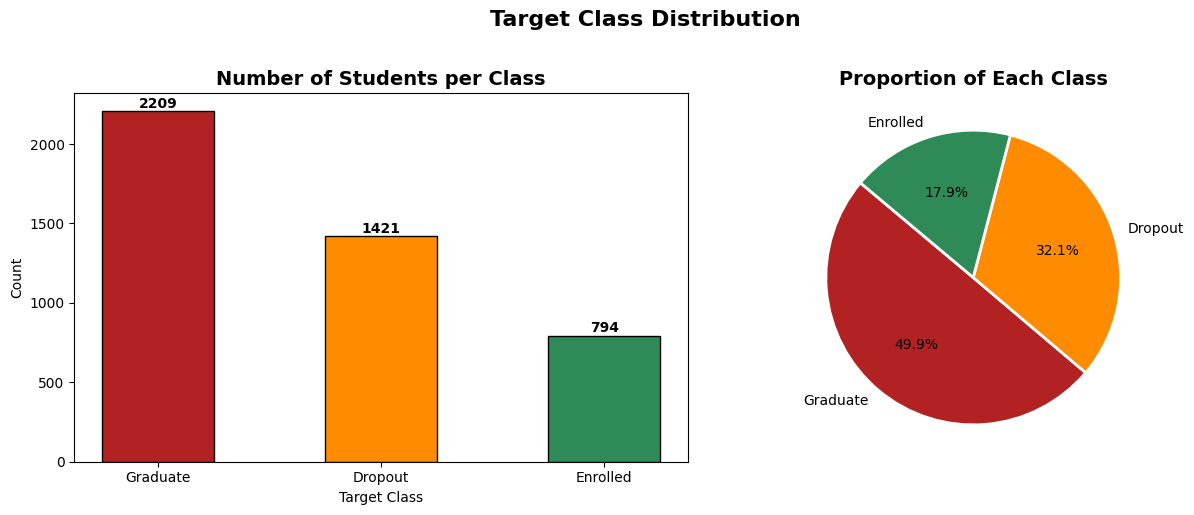

In [8]:
target_value_counts = student_dataframe['Target'].value_counts()
target_percentages  = student_dataframe['Target'].value_counts(normalize=True) * 100
color_list = ['firebrick', 'darkorange', 'seagreen']
target_color_map = {'Dropout': 'firebrick', 'Enrolled': 'darkorange', 'Graduate': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(target_value_counts.index, target_value_counts.values,
            color=color_list, edgecolor='black', width=0.5)
axes[0].set_title('Number of Students per Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Class'); axes[0].set_ylabel('Count')
for i, v in enumerate(target_value_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_value_counts.values, labels=target_value_counts.index,
            autopct='%1.1f%%', colors=color_list, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Each Class', fontsize=14, fontweight='bold')

plt.suptitle('Target Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()



The dataset has three classes. Graduates make up about half the data, Dropout students around a third, and Enrolled students roughly 18%. This imbalance is a problem, a model that predicted Graduate for every student would already get 50% accuracy without learning anything. That is why we apply SMOTE during preprocessing to balance the training classes before model training.

### 3.2 — Academic Performance by Class

Violin plots show the full distribution shape, not just quartiles. They reveal things a boxplot hides including the cluster of Dropout students with a zero grade, which represents students who stopped attending early in the semester.

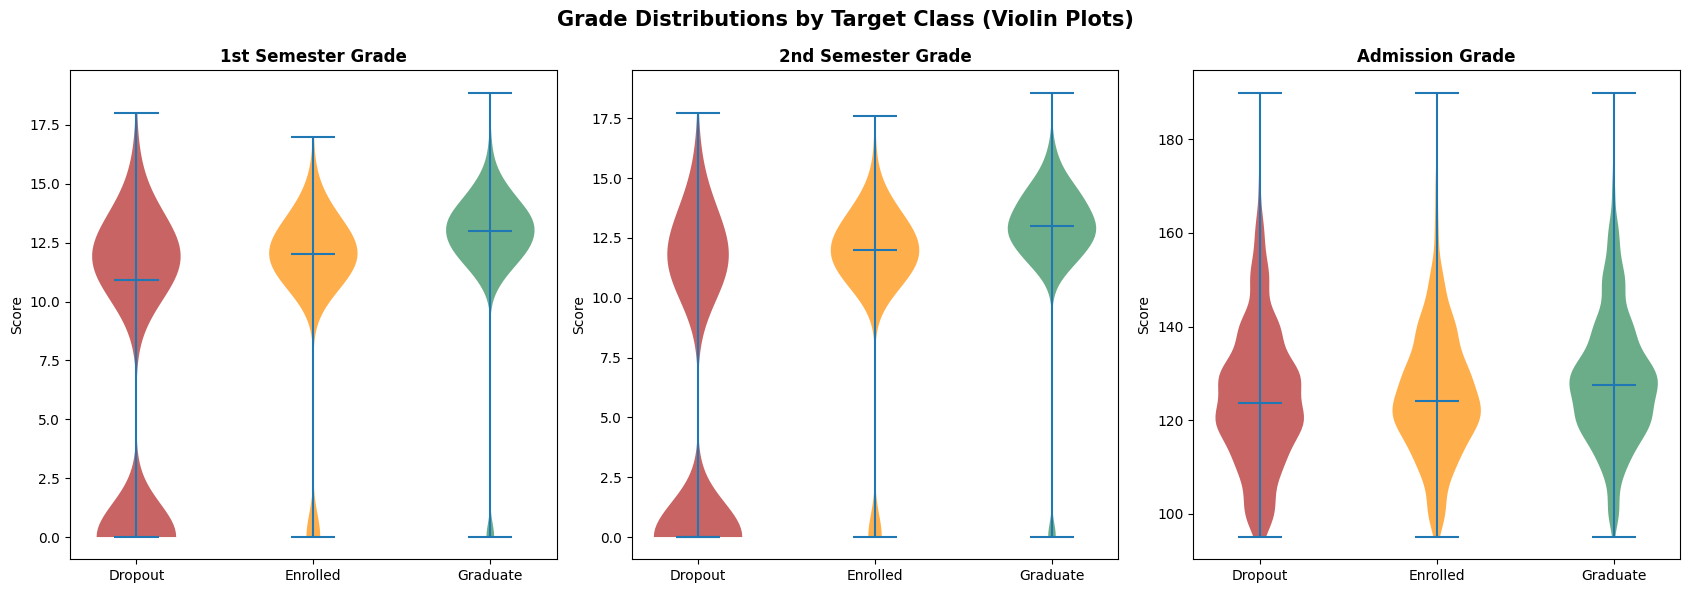

In [9]:
# Violin plots for key continuous features — more informative than boxplots
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

violin_features = [
    ('Curricular units 1st sem (grade)', '1st Semester Grade'),
    ('Curricular units 2nd sem (grade)', '2nd Semester Grade'),
    ('Admission grade',                  'Admission Grade'),
]
violin_palette = {'Dropout': 'firebrick', 'Enrolled': 'darkorange', 'Graduate': 'seagreen'}

for idx, (col, label) in enumerate(violin_features):
    plot_data = [
        student_dataframe[student_dataframe['Target'] == cls][col].values
        for cls in ['Dropout', 'Enrolled', 'Graduate']
    ]
    parts = axes[idx].violinplot(plot_data, positions=[0, 1, 2], showmedians=True,
                                  showextrema=True)
    for i, (pc, color) in enumerate(zip(parts['bodies'],
                                        ['firebrick', 'darkorange', 'seagreen'])):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_xticklabels(['Dropout', 'Enrolled', 'Graduate'], fontsize=10)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')

plt.suptitle('Grade Distributions by Target Class (Violin Plots)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_violin_grades.png', bbox_inches='tight')
plt.show()



The most important pattern here is in the 1st semester grade for Dropout students, there is a visible cluster at zero. These are students who stopped attending early and never completed any assessments. Graduate students show consistently higher grades across both semesters. Enrolled students sit in the middle, which is part of why they are harder to classify.

### 3.3 — Correlation with Dropout

We focus on the top 20 features most correlated with the Dropout label instead of plotting all 36 at once. This keeps the heatmap readable and shows only what actually matters.

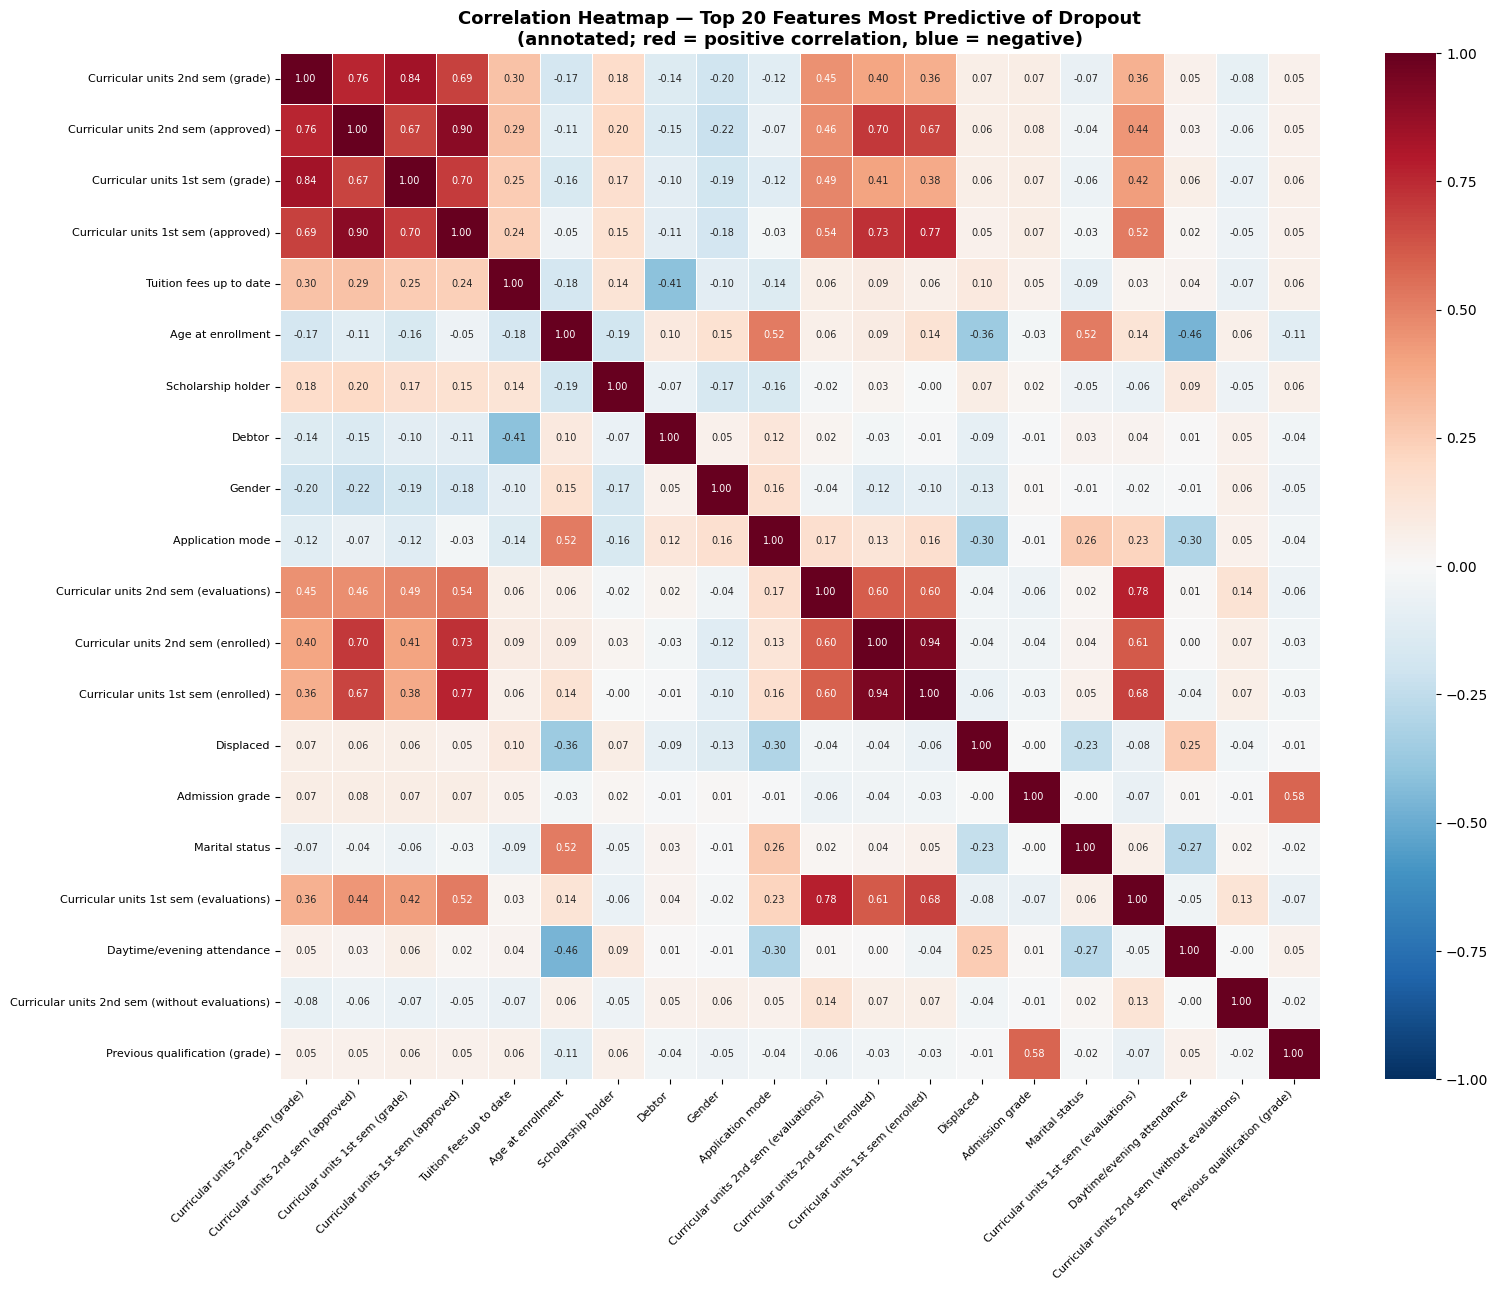

Top 10 highest-correlation feature pairs (abs value):
Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.945
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.943
Mother's occupation                     Father's occupation                       0.910
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.904
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837
Nacionality                             International                             0.791
Curricular units 1st sem (evaluations)  Curricular units 2nd sem (evaluations)    0.779
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774
Curricular units 1st sem (enrolled)     Curricular units 1st sem (approved)       0.769
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.761
dtype: float64

The VIF analysis below quantifies this precisely.


In [10]:
# Focused, annotated correlation heatmap — top 20 features by dropout correlation
# A 36x36 heatmap without annotations is decorative, not analytical.
# We instead: rank features by abs correlation with the Dropout label,
# plot only the top 20 with annotations so every value is readable.

binary_dropout_heat = (student_dataframe['Target'] == 'Dropout').astype(int)
numeric_cols = student_dataframe.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = student_dataframe[numeric_cols].corr()

corr_with_dropout = student_dataframe[numeric_cols].corrwith(binary_dropout_heat).abs()
top20_features = corr_with_dropout.sort_values(ascending=False).head(20).index.tolist()
corr_top20 = corr_matrix.loc[top20_features, top20_features]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_top20, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='white'
)
ax.set_title(
    'Correlation Heatmap — Top 20 Features Most Predictive of Dropout\n'
    '(annotated; red = positive correlation, blue = negative)',
    fontsize=13, fontweight='bold'
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap_top20.png', bbox_inches='tight')
plt.show()

print('Top 10 highest-correlation feature pairs (abs value):')
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper.stack().abs().sort_values(ascending=False).head(10)
print(top_corr.round(3))

print()
print('The VIF analysis below quantifies this precisely.')


### 3.4 — Feature-Level Correlation (Point-Biserial)

Measures the statistical correlation between each numeric feature and a binary dropout label. This gives a ranked list of the strongest individual predictors before any model is built.

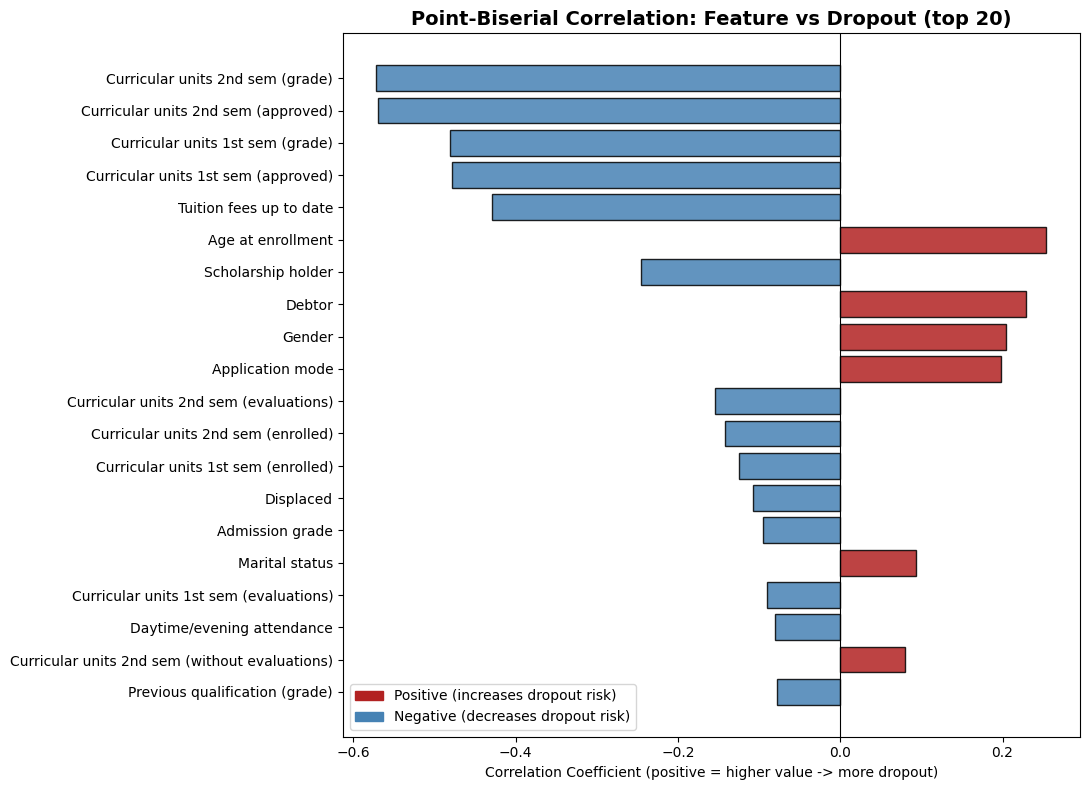

Top features by correlation with Dropout:
                            Feature  Correlation with Dropout Significant (p<0.05)
   Curricular units 2nd sem (grade)                   -0.5718                  Yes
Curricular units 2nd sem (approved)                   -0.5695                  Yes
   Curricular units 1st sem (grade)                   -0.4807                  Yes
Curricular units 1st sem (approved)                   -0.4791                  Yes
            Tuition fees up to date                   -0.4291                  Yes
                  Age at enrollment                    0.2542                  Yes
                 Scholarship holder                   -0.2454                  Yes
                             Debtor                    0.2294                  Yes
                             Gender                    0.2040                  Yes
                   Application mode                    0.1985                  Yes


In [11]:
# Binary dropout label for correlation analysis
binary_dropout_for_corr = (student_dataframe['Target'] == 'Dropout').astype(int)

correlation_rows = []
for col in student_dataframe.select_dtypes(include=[np.number]).columns:
    corr_val, p_val = stats.pointbiserialr(
        binary_dropout_for_corr, student_dataframe[col]
    )
    correlation_rows.append({
        'Feature': col,
        'Correlation with Dropout': round(corr_val, 4),
        'p-value': round(p_val, 6),
        'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

corr_target_df = pd.DataFrame(correlation_rows)
corr_target_df = corr_target_df.sort_values('Correlation with Dropout', key=abs, ascending=False)

# Plot top 20
top20 = corr_target_df.head(20)
colors_for_corr = ['firebrick' if v > 0 else 'steelblue' for v in top20['Correlation with Dropout']]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top20['Feature'], top20['Correlation with Dropout'],
               color=colors_for_corr, edgecolor='black', alpha=0.85)
ax.set_title('Point-Biserial Correlation: Feature vs Dropout (top 20)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient (positive = higher value -> more dropout)')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()

red_patch  = mpatches.Patch(color='firebrick', label='Positive (increases dropout risk)')
blue_patch = mpatches.Patch(color='steelblue', label='Negative (decreases dropout risk)')
ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.savefig('plot_10_pointbiserial_correlation.png', bbox_inches='tight')
plt.show()

print("Top features by correlation with Dropout:")
print(corr_target_df[['Feature', 'Correlation with Dropout', 'Significant (p<0.05)']].head(10).to_string(index=False))


The strongest individual predictors of dropout are all academic: units approved, approval rate, and average grade. Financial features like tuition fees and debtor status also appear in the top 10. Macroeconomic features (GDP, unemployment rate) have very low correlation individually and will not be the primary drivers in the model.

## Section 4 — Data Cleaning

Five checks are run on the raw data before modelling.

| Step | What We Check |
|---|---|
| 1 | Missing values |
| 2 | Duplicate rows |
| 3 | Binary column validation |
| 4 | Outlier treatment (IQR Winsorization) |
| 5 | Target column integrity |

**Why Winsorization instead of deletion?** Capping outliers at IQR boundaries keeps the full dataset size while limiting the influence of extreme values. It is only applied to continuous grade and score columns, not binary or count columns.

In [12]:
cleaned_dataframe = student_dataframe.copy()

missing = cleaned_dataframe.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print('No missing values found in any column.')
else:
    print(f'Found {total_missing} missing values:')
    print(missing[missing > 0])
    numeric_nulls = cleaned_dataframe.select_dtypes(include=[np.number]).columns
    cleaned_dataframe[numeric_nulls] = cleaned_dataframe[numeric_nulls].fillna(
        cleaned_dataframe[numeric_nulls].median()
    )
    print('   Filled with column median.')


No missing values found in any column.


In [13]:
n_dup = cleaned_dataframe.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
if n_dup > 0:
    cleaned_dataframe = cleaned_dataframe.drop_duplicates().reset_index(drop=True)
    print(f'Removed {n_dup} duplicates.')
else:
    print('No duplicates found.')
print(f'Shape: {cleaned_dataframe.shape}')


Duplicate rows: 0
No duplicates found.
Shape: (4424, 37)


In [14]:
binary_columns = ['Displaced', 'Educational special needs', 'Debtor',
                  'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
for col in binary_columns:
    if col in cleaned_dataframe.columns:
        unique_vals = cleaned_dataframe[col].unique()
        status = 'OK' if set(unique_vals).issubset({0, 1}) else 'WARNING'
        print(f'  [{status}] {col}: {unique_vals}')


  [OK] Displaced: [1 0]
  [OK] Educational special needs: [0 1]
  [OK] Debtor: [0 1]
  [OK] Tuition fees up to date: [1 0]
  [OK] Gender: [1 0]
  [OK] Scholarship holder: [0 1]
  [OK] International: [0 1]


In [15]:

outlier_cols = [
    'Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'GDP'
]

outlier_rows = []
for col in outlier_cols:
    if col not in cleaned_dataframe.columns:
        continue
    q1  = cleaned_dataframe[col].quantile(0.25)
    q3  = cleaned_dataframe[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((cleaned_dataframe[col] < lo) | (cleaned_dataframe[col] > hi)).sum()
    pct   = n_out / len(cleaned_dataframe) * 100
    cleaned_dataframe[col] = cleaned_dataframe[col].clip(lower=lo, upper=hi)
    outlier_rows.append({'Column': col, 'Lower': round(lo,2),
                          'Upper': round(hi,2), 'Capped': n_out, 'Pct': round(pct,1)})

outlier_df = pd.DataFrame(outlier_rows)
print(outlier_df.to_string(index=False))
print()


                          Column  Lower  Upper  Capped  Pct
               Age at enrollment  10.00  34.00     441 10.0
                 Admission grade  92.55 160.15      86  1.9
  Previous qualification (grade) 102.50 162.50     179  4.0
Curricular units 1st sem (grade)   7.40  17.00     726 16.4
Curricular units 2nd sem (grade)   6.87  17.21     877 19.8
               Unemployment rate   2.65  20.65       0  0.0
                             GDP  -6.94   7.02       0  0.0



In [16]:
valid_classes = ['Dropout', 'Enrolled', 'Graduate']
invalid = cleaned_dataframe[~cleaned_dataframe['Target'].isin(valid_classes)]
if len(invalid) > 0:
    print(f'Removing {len(invalid)} rows with invalid target.')
    cleaned_dataframe = cleaned_dataframe[cleaned_dataframe['Target'].isin(valid_classes)]
else:
    print('All target values are valid.')

print(f'\nFinal cleaned dataset shape: {cleaned_dataframe.shape}')
print('\nTarget distribution after cleaning:')
print(cleaned_dataframe['Target'].value_counts())
cleaned_dataframe.to_csv('student_data_cleaned.csv', index=False)
print('\nCleaned dataset saved as student_data_cleaned.csv')


All target values are valid.

Final cleaned dataset shape: (4424, 37)

Target distribution after cleaning:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Cleaned dataset saved as student_data_cleaned.csv


## Section 5 — Feature Engineering

We create 10 new features from the existing columns. These capture academic progression and financial risk more directly than the raw counts.

| New Feature | What It Captures |
|---|---|
| Total Units Approved | Approved units across both semesters |
| Total Units Enrolled | Enrolled units across both semesters |
| Approval Rate 1st Sem | % of enrolled units passed in semester 1 |
| Approval Rate 2nd Sem | % of enrolled units passed in semester 2 |
| Overall Approval Rate | Combined pass rate across both semesters |
| Average Grade Both Sems | Mean grade across both semesters |
| Grade Improvement | Grade change from semester 1 to 2 |
| Financial Risk Score | Debtor status + unpaid fees (0 to 2 scale) |
| Academic Engagement Score | Evaluations attended relative to enrolled units |
| Sem2 vs Sem1 Units Ratio | Change in unit load between semesters |

In [17]:
fe_df = cleaned_dataframe.copy()

# Total approved units across both semesters
fe_df['Total Units Approved'] = (
    fe_df['Curricular units 1st sem (approved)'] +
    fe_df['Curricular units 2nd sem (approved)']
)

# Total enrolled units across both semesters
fe_df['Total Units Enrolled'] = (
    fe_df['Curricular units 1st sem (enrolled)'] +
    fe_df['Curricular units 2nd sem (enrolled)']
)

# Approval rate semester 1 (zero-division safe)
fe_df['Approval Rate 1st Sem'] = np.where(
    fe_df['Curricular units 1st sem (enrolled)'] > 0,
    fe_df['Curricular units 1st sem (approved)'] /
    fe_df['Curricular units 1st sem (enrolled)'], 0.0
)

# Approval rate semester 2
fe_df['Approval Rate 2nd Sem'] = np.where(
    fe_df['Curricular units 2nd sem (enrolled)'] > 0,
    fe_df['Curricular units 2nd sem (approved)'] /
    fe_df['Curricular units 2nd sem (enrolled)'], 0.0
)

# Overall approval rate
fe_df['Overall Approval Rate'] = np.where(
    fe_df['Total Units Enrolled'] > 0,
    fe_df['Total Units Approved'] / fe_df['Total Units Enrolled'], 0.0
)

# Average grade across both semesters
fe_df['Average Grade Both Sems'] = (
    fe_df['Curricular units 1st sem (grade)'] +
    fe_df['Curricular units 2nd sem (grade)']
) / 2

# Grade improvement from semester 1 to 2
fe_df['Grade Improvement'] = (
    fe_df['Curricular units 2nd sem (grade)'] -
    fe_df['Curricular units 1st sem (grade)']
)

# Financial risk score (0 = no risk, 2 = maximum risk)
fe_df['Financial Risk Score'] = (
    fe_df['Debtor'] + (1 - fe_df['Tuition fees up to date'])
)

# Academic engagement (evaluations attended / enrolled units)
fe_df['Academic Engagement Score'] = np.where(
    fe_df['Total Units Enrolled'] > 0,
    (fe_df['Curricular units 1st sem (evaluations)'] +
     fe_df['Curricular units 2nd sem (evaluations)']) /
    fe_df['Total Units Enrolled'], 0.0
)

# Sem2 vs Sem1 enrolled units ratio
fe_df['Sem2 vs Sem1 Units Ratio'] = np.where(
    fe_df['Curricular units 1st sem (enrolled)'] > 0,
    fe_df['Curricular units 2nd sem (enrolled)'] /
    fe_df['Curricular units 1st sem (enrolled)'], 1.0
)

new_feature_names = [
    'Total Units Approved', 'Total Units Enrolled', 'Approval Rate 1st Sem',
    'Approval Rate 2nd Sem', 'Overall Approval Rate', 'Average Grade Both Sems',
    'Grade Improvement', 'Financial Risk Score', 'Academic Engagement Score',
    'Sem2 vs Sem1 Units Ratio'
]
print(f'\nNew features summary:')
print(fe_df[new_feature_names].describe().T[['mean','std','min','max']].round(3))



New features summary:
                             mean    std    min     max
Total Units Approved        9.142  5.961  0.000  43.000
Total Units Enrolled       12.503  4.609  0.000  46.000
Approval Rate 1st Sem       0.698  0.365  0.000   1.000
Approval Rate 2nd Sem       0.660  0.383  0.000   1.000
Overall Approval Rate       0.679  0.362  0.000   1.000
Average Grade Both Sems    11.711  2.359  7.137  17.104
Grade Improvement          -0.259  1.511 -9.268   8.600
Financial Risk Score        0.233  0.539  0.000   2.000
Academic Engagement Score   1.275  0.535  0.000   3.333
Sem2 vs Sem1 Units Ratio    1.012  0.213  0.200   6.000


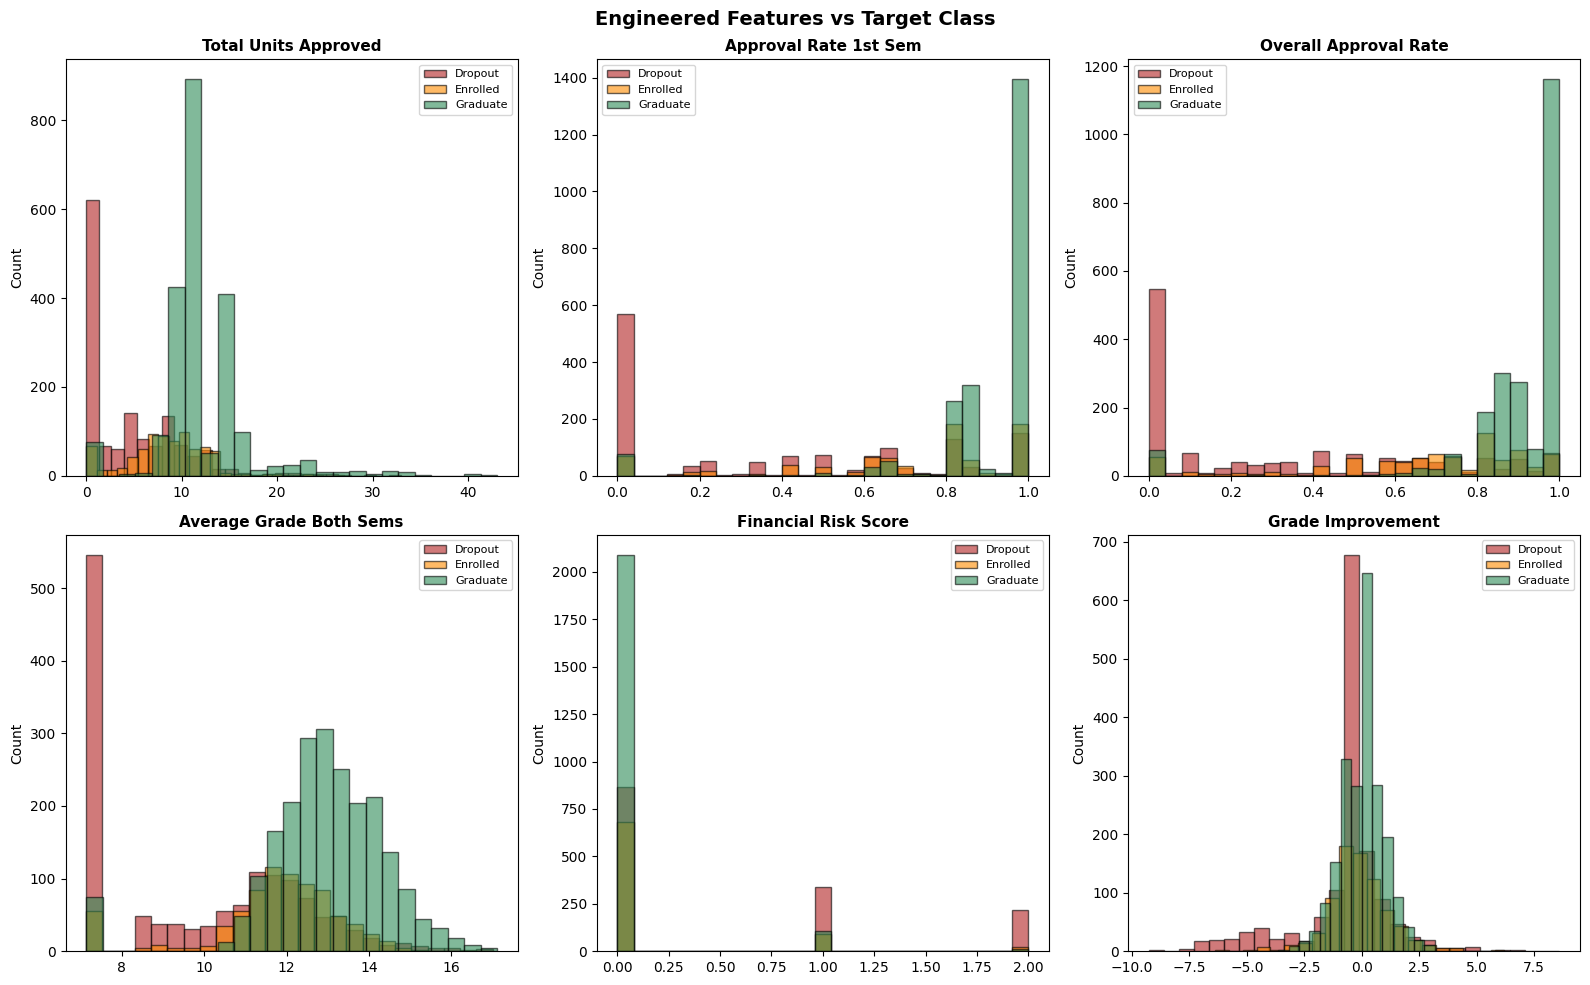

In [18]:
# Visualise new engineered features vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = [
    'Total Units Approved', 'Approval Rate 1st Sem', 'Overall Approval Rate',
    'Average Grade Both Sems', 'Financial Risk Score', 'Grade Improvement'
]

for idx, feat in enumerate(plot_features):
    for cls, color in target_color_map.items():
        vals = fe_df[fe_df['Target'] == cls][feat]
        axes[idx].hist(vals, bins=25, alpha=0.6, label=cls, color=color, edgecolor='black')
    axes[idx].set_title(feat, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count'); axes[idx].legend(fontsize=8)

plt.suptitle('Engineered Features vs Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_11_engineered_features.png', bbox_inches='tight')
plt.show()


## Section 6 — Preprocessing

| Step | Details |
|---|---|
| Target encoding | Dropout = 0, Enrolled = 1, Graduate = 2 |
| Train/test split | 80/20, stratified by class |
| Scaling | StandardScaler fitted on training data only |
| Class balancing | SMOTE applied to training data only |

**Scaler on training only:** Fitting the scaler on the full dataset before splitting would leak test set statistics into training. Fitting on training only keeps evaluation honest.

**SMOTE on training only:** Synthetic samples should never appear in the test set. If they do, evaluation scores will be inflated.

In [19]:
label_encoder = LabelEncoder()
fe_df['Target Encoded'] = label_encoder.fit_transform(fe_df['Target'])

for idx, name in enumerate(label_encoder.classes_):
    print(f'  {idx} -> {name}')
target_class_names = list(label_encoder.classes_)


  0 -> Dropout
  1 -> Enrolled
  2 -> Graduate


In [20]:
all_feature_columns = [
    c for c in fe_df.columns
    if c not in ['Target', 'Target Encoded', 'Target Encoded Vif']
]
feature_matrix_X = fe_df[all_feature_columns]
target_vector_y  = fe_df['Target Encoded']

print(f'Feature matrix shape: {feature_matrix_X.shape}')


Feature matrix shape: (4424, 46)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix_X, target_vector_y,
    test_size=0.20, random_state=42, stratify=target_vector_y
)
print(f'Training set: {X_train.shape[0]} students')
print(f'Test set:     {X_test.shape[0]} students')
print(f'\nClass distribution in training set:')
print(pd.Series(y_train).map({0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}).value_counts())


Training set: 3539 students
Test set:     885 students

Class distribution in training set:
Target Encoded
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64


In [22]:
# Fit scaler ONLY on training data — transform test separately
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_matrix_X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_matrix_X.columns
)


In [23]:
# SMOTE applied ONLY to training data
print('Class distribution BEFORE SMOTE:')
print(pd.Series(y_train).value_counts().rename(index={0:'Dropout',1:'Enrolled',2:'Graduate'}))

smote_resampler = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote_resampler.fit_resample(X_train_scaled, y_train)

print('\nClass distribution AFTER SMOTE:')
print(pd.Series(y_train_balanced).value_counts().rename(index={0:'Dropout',1:'Enrolled',2:'Graduate'}))
print(f'\nTraining size before SMOTE: {len(y_train)}')
print(f'Training size after  SMOTE: {len(y_train_balanced)}')


Class distribution BEFORE SMOTE:
Target Encoded
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Target Encoded
Graduate    1767
Dropout     1767
Enrolled    1767
Name: count, dtype: int64

Training size before SMOTE: 3539
Training size after  SMOTE: 5301


After SMOTE, all three classes have equal representation in the training set. The model now sees the same number of examples for each class during training. The test set is left untouched so that our evaluation reflects real-world class proportions.

In [24]:
# Save preprocessing artifacts
feature_column_names = list(feature_matrix_X.columns)
with open('scaler.pkl',          'wb') as f: pickle.dump(scaler, f)
with open('label_encoder.pkl',   'wb') as f: pickle.dump(label_encoder, f)
with open('feature_columns.pkl', 'wb') as f: pickle.dump(feature_column_names, f)


## Section 7 — Model Training and Evaluation

We train 9 models on the same SMOTE-balanced training data and evaluate all of them on the same held-out test set.

| Model | Notes |
|---|---|
| Dummy Classifier | Baseline floor — every other model must beat this |
| Logistic Regression | Linear baseline |
| K-Nearest Neighbours | k chosen by CV elbow plot |
| Naive Bayes | Probabilistic baseline |
| Decision Tree | Interpretable tree model |
| Random Forest | Ensemble of trees |
| Gradient Boosting | Sequential boosting |
| XGBoost | Tuned via GridSearchCV |
| Neural Network (MLP) | Deep learning model |

**Metrics reported:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

Best k by CV F1-weighted: k = 1  (score = 0.8303)


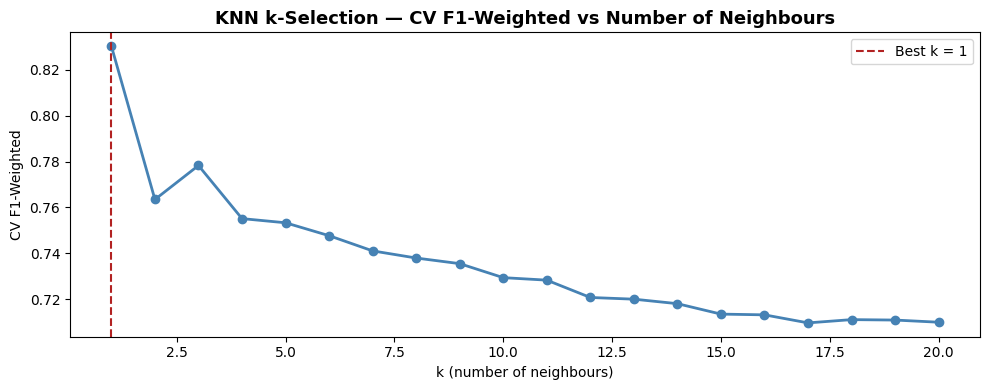


Training all base models...


In [25]:
dropout_class_index = list(label_encoder.classes_).index('Dropout')

# n_neighbors=5 is the sklearn default. We validate this choice by evaluating
# weighted F1 across k=1..20 on the balanced training data with 3-fold CV.
# This ensures our KNN configuration is justified, not arbitrary.
k_range  = range(1, 21)
k_scores = []
kf_elbow = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_k, X_train_balanced, y_train_balanced,
                            cv=kf_elbow, scoring='f1_weighted', n_jobs=-1).mean()
    k_scores.append(score)

best_k = list(k_range)[k_scores.index(max(k_scores))]
print(f'Best k by CV F1-weighted: k = {best_k}  (score = {max(k_scores):.4f})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), k_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(x=best_k, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'Best k = {best_k}')
ax.set_title('KNN k-Selection — CV F1-Weighted vs Number of Neighbours',
             fontsize=13, fontweight='bold')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('CV F1-Weighted')
ax.legend()
plt.tight_layout()
plt.savefig('plot_knn_elbow.png', bbox_inches='tight')
plt.show()

# DummyClassifier (stratified) predicts classes randomly according to training
# class frequencies. This is the minimum acceptable performance floor —
# any model that cannot beat DummyClassifier has learned nothing from the data.
all_models_dict = {
    'Dummy Baseline':       DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=best_k),
    'Naive Bayes':          GaussianNB(),
    'Decision Tree':        DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':              XGBClassifier(
                                n_estimators=150, learning_rate=0.1, max_depth=6,
                                use_label_encoder=False, eval_metric='mlogloss', random_state=42
                            ),
}

trained_models    = {}
model_predictions = {}

print('\nTraining all base models...')
for name, model in all_models_dict.items():
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test_scaled)
    trained_models[name]    = model
    model_predictions[name] = preds


In [26]:
# Neural Network (MLP) with Batch Normalisation and Dropout regularisation
n_features = X_train_balanced.shape[1]
n_classes  = len(target_class_names)

nn_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(n_classes, activation='softmax')
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
nn_model.summary()

nn_history = nn_model.fit(
    X_train_balanced, y_train_balanced,
    epochs=50, batch_size=64, validation_split=0.15, verbose=0
)

nn_preds = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)
trained_models['Neural Network (MLP)']    = nn_model
model_predictions['Neural Network (MLP)'] = nn_preds


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,915 (214.51 KB)

 Trainable params: 54,147 (211.51 KB)

 Non-trainable params: 768 (3.00 KB)

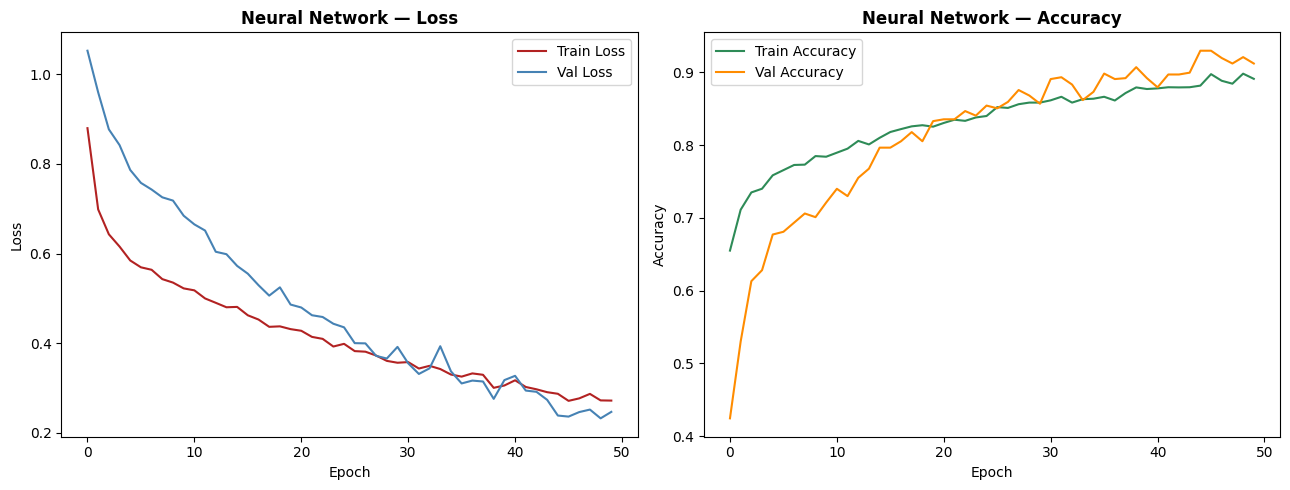

In [27]:
# NN training history
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(nn_history.history['loss'],     label='Train Loss',  color='firebrick')
axes[0].plot(nn_history.history['val_loss'], label='Val Loss',    color='steelblue')
axes[0].set_title('Neural Network — Loss',     fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(nn_history.history['accuracy'],     label='Train Accuracy', color='seagreen')
axes[1].plot(nn_history.history['val_accuracy'], label='Val Accuracy',   color='darkorange')
axes[1].set_title('Neural Network — Accuracy',  fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('plot_12_nn_training.png', bbox_inches='tight')
plt.show()


### 7.1 — GridSearchCV: XGBoost Hyperparameter Tuning

We search over `n_estimators`, `max_depth`, and `learning_rate` using 3-fold cross-validation.

SMOTE is wrapped inside the pipeline (`ImbPipeline`) so synthetic samples are only generated from each fold's training split. If SMOTE ran before CV on the full training set, the same synthetic samples would appear in both training and validation splits making tuning scores look better than they really are.

In [28]:
# param_grid keys use 'clf__' prefix to target the classifier step inside the pipeline.

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(
                  use_label_encoder=False, eval_metric='mlogloss', random_state=42
              ))
])

param_grid = {
    'clf__n_estimators':  [100, 200],
    'clf__max_depth':     [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
# Key: X_train_scaled (pre-SMOTE), y_train (original labels)
# SMOTE only sees each fold's training split — no leakage into validation
grid_search.fit(X_train_scaled, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV F1 (weighted, leakage-free): {grid_search.best_score_:.4f}')

# Extract the fitted XGBoost step from the best pipeline
tuned_xgb = grid_search.best_estimator_.named_steps['clf']
tuned_xgb_preds = tuned_xgb.predict(X_test_scaled)
tuned_f1 = f1_score(y_test, tuned_xgb_preds, average='weighted')

base_f1 = f1_score(y_test, model_predictions['XGBoost'], average='weighted')
print(f'\nBase XGBoost test F1:  {base_f1:.4f}')
print(f'Tuned XGBoost test F1: {tuned_f1:.4f}')

# Update trained models with tuned version
trained_models['XGBoost']    = tuned_xgb
model_predictions['XGBoost'] = tuned_xgb_preds


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200}
Best CV F1 (weighted, leakage-free): 0.7804

Base XGBoost test F1:  0.7582
Tuned XGBoost test F1: 0.7616


### 7.2 — Model Comparison

In [29]:
results_rows = []

for model_name, preds in model_predictions.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds,        average='weighted', zero_division=0)

    try:
        model_obj = trained_models[model_name]
        if model_name == 'Neural Network (MLP)':
            proba = nn_model.predict(X_test_scaled, verbose=0)
        elif hasattr(model_obj, 'predict_proba'):
            proba = model_obj.predict_proba(X_test_scaled)
        else:
            proba = model_obj.decision_function(X_test_scaled)
        y_bin = label_binarize(y_test, classes=[0, 1, 2])
        roc   = roc_auc_score(y_bin, proba, multi_class='ovr', average='weighted')
    except Exception:
        roc = float('nan')

    results_rows.append({
        'Model':     model_name,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1-Score':  round(f1 * 100, 2),
        'ROC-AUC':   round(roc, 4) if not np.isnan(roc) else 'N/A'
    })

results_df = pd.DataFrame(results_rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('=' * 80)
print('MODEL COMPARISON TABLE (sorted by F1-Score)')
print('=' * 80)
print(results_df.to_string(index=False))
best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')


MODEL COMPARISON TABLE (sorted by F1-Score)
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
             XGBoost     76.16      76.30   76.16     76.16   0.9072
   Gradient Boosting     75.59      75.91   75.59     75.68   0.9023
       Random Forest     74.92      76.76   74.92     75.51   0.9049
 Logistic Regression     73.33      76.41   73.33     74.42   0.8938
       Decision Tree     71.75      74.78   71.75     72.82   0.8536
         Naive Bayes     70.40      72.65   70.40     71.21   0.8427
Neural Network (MLP)     70.51      71.10   70.51     70.79   0.8598
K-Nearest Neighbours     62.94      64.84   62.94     63.79   0.7172
      Dummy Baseline     33.79      38.95   33.79     35.01   0.5041

Best model: XGBoost


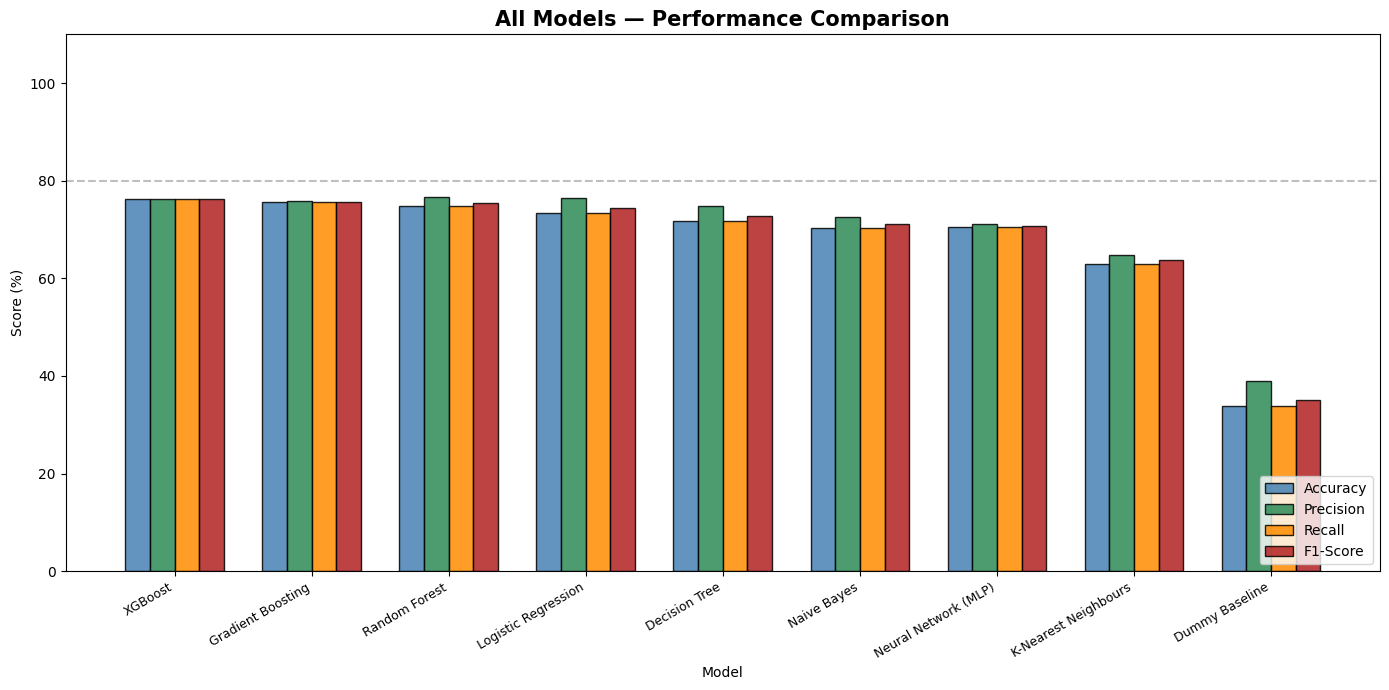

In [30]:
# Visual model comparison
fig, ax = plt.subplots(figsize=(14, 7))
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = results_df['Model'].tolist()
bar_w = 0.18
positions = np.arange(len(model_names))
bar_colors = ['steelblue', 'seagreen', 'darkorange', 'firebrick']

for mi, metric in enumerate(metric_cols):
    vals = results_df[metric].values
    offset = (mi - 1.5) * bar_w
    ax.bar(positions + offset, vals, bar_w,
           label=metric, color=bar_colors[mi], alpha=0.85, edgecolor='black')

ax.set_xlabel('Model'); ax.set_ylabel('Score (%)')
ax.set_title('All Models — Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend(loc='lower right')
ax.set_ylim(0, 110)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_13_model_comparison.png', bbox_inches='tight')
plt.show()


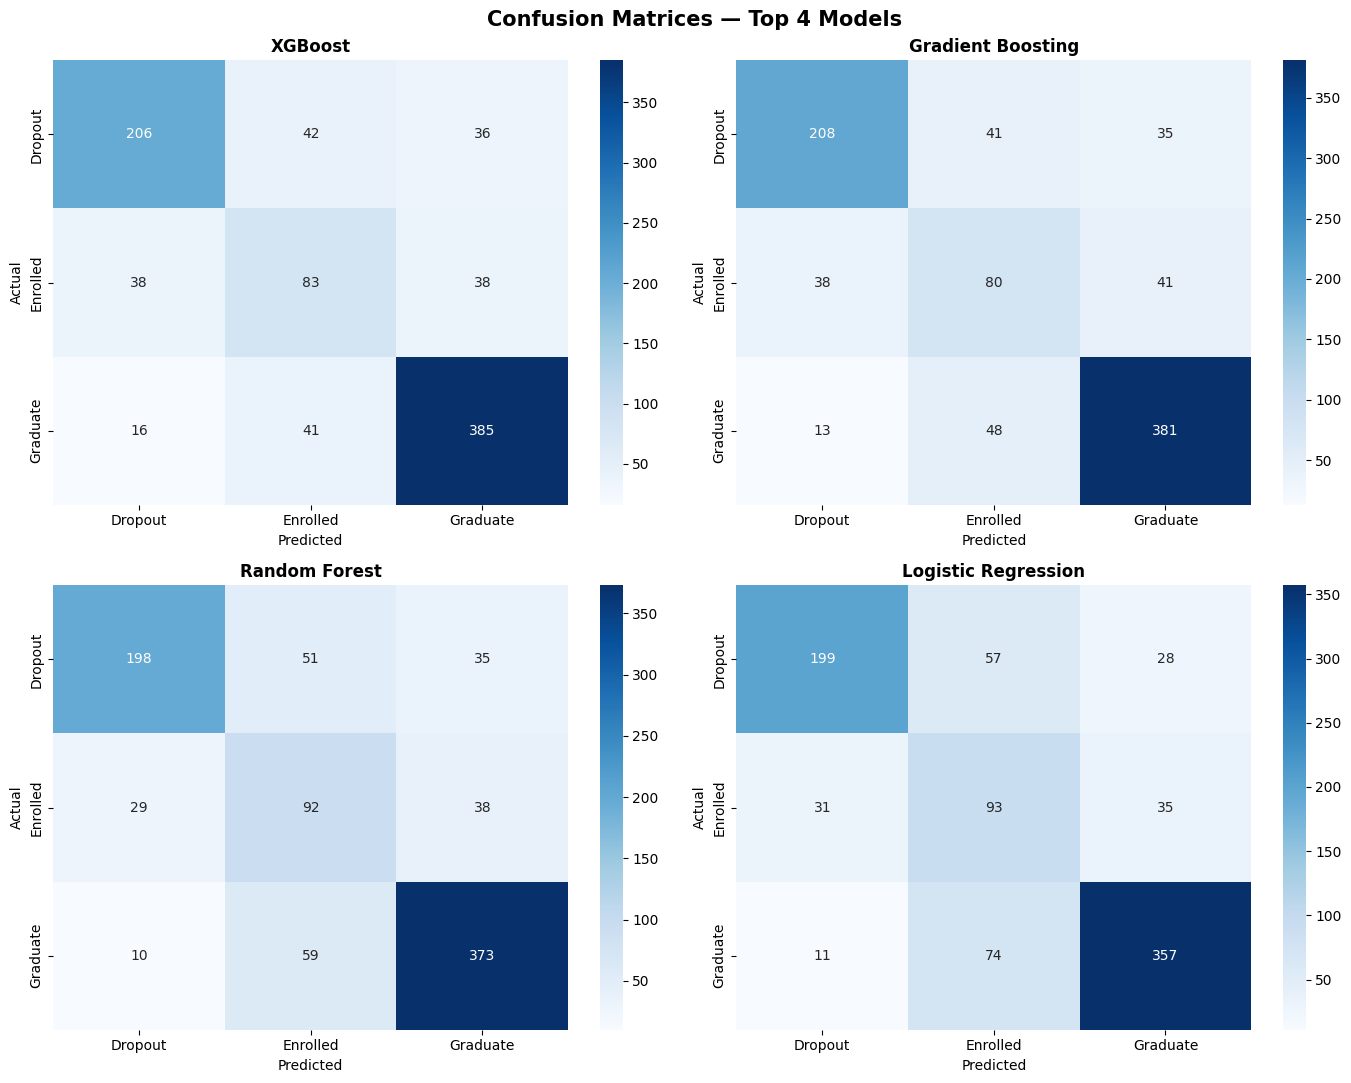

In [31]:
# Confusion matrices — top 4 models
top4 = results_df.head(4)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for pi, mname in enumerate(top4):
    cm = confusion_matrix(y_test, model_predictions[mname])
    sns.heatmap(cm, ax=axes[pi], annot=True, fmt='d', cmap='Blues',
                xticklabels=target_class_names, yticklabels=target_class_names)
    axes[pi].set_title(mname, fontsize=12, fontweight='bold')
    axes[pi].set_xlabel('Predicted'); axes[pi].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_confusion_matrices.png', bbox_inches='tight')
plt.show()


In [32]:
# Detailed classification report for the best model
best_preds = model_predictions[best_model_name]
print(f'Classification Report — {best_model_name}')
print('=' * 65)
print(classification_report(y_test, best_preds, target_names=target_class_names))


Classification Report — XGBoost
              precision    recall  f1-score   support

     Dropout       0.79      0.73      0.76       284
    Enrolled       0.50      0.52      0.51       159
    Graduate       0.84      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.76      0.76      0.76       885



The classification report shows precision, recall, and F1 for each class separately. Dropout and Graduate typically perform well. The Enrolled class will have the lowest F1 and this is expected and explained in Section 7.5. The overall accuracy looks good partly because the model handles the majority classes (Dropout and Graduate) well.

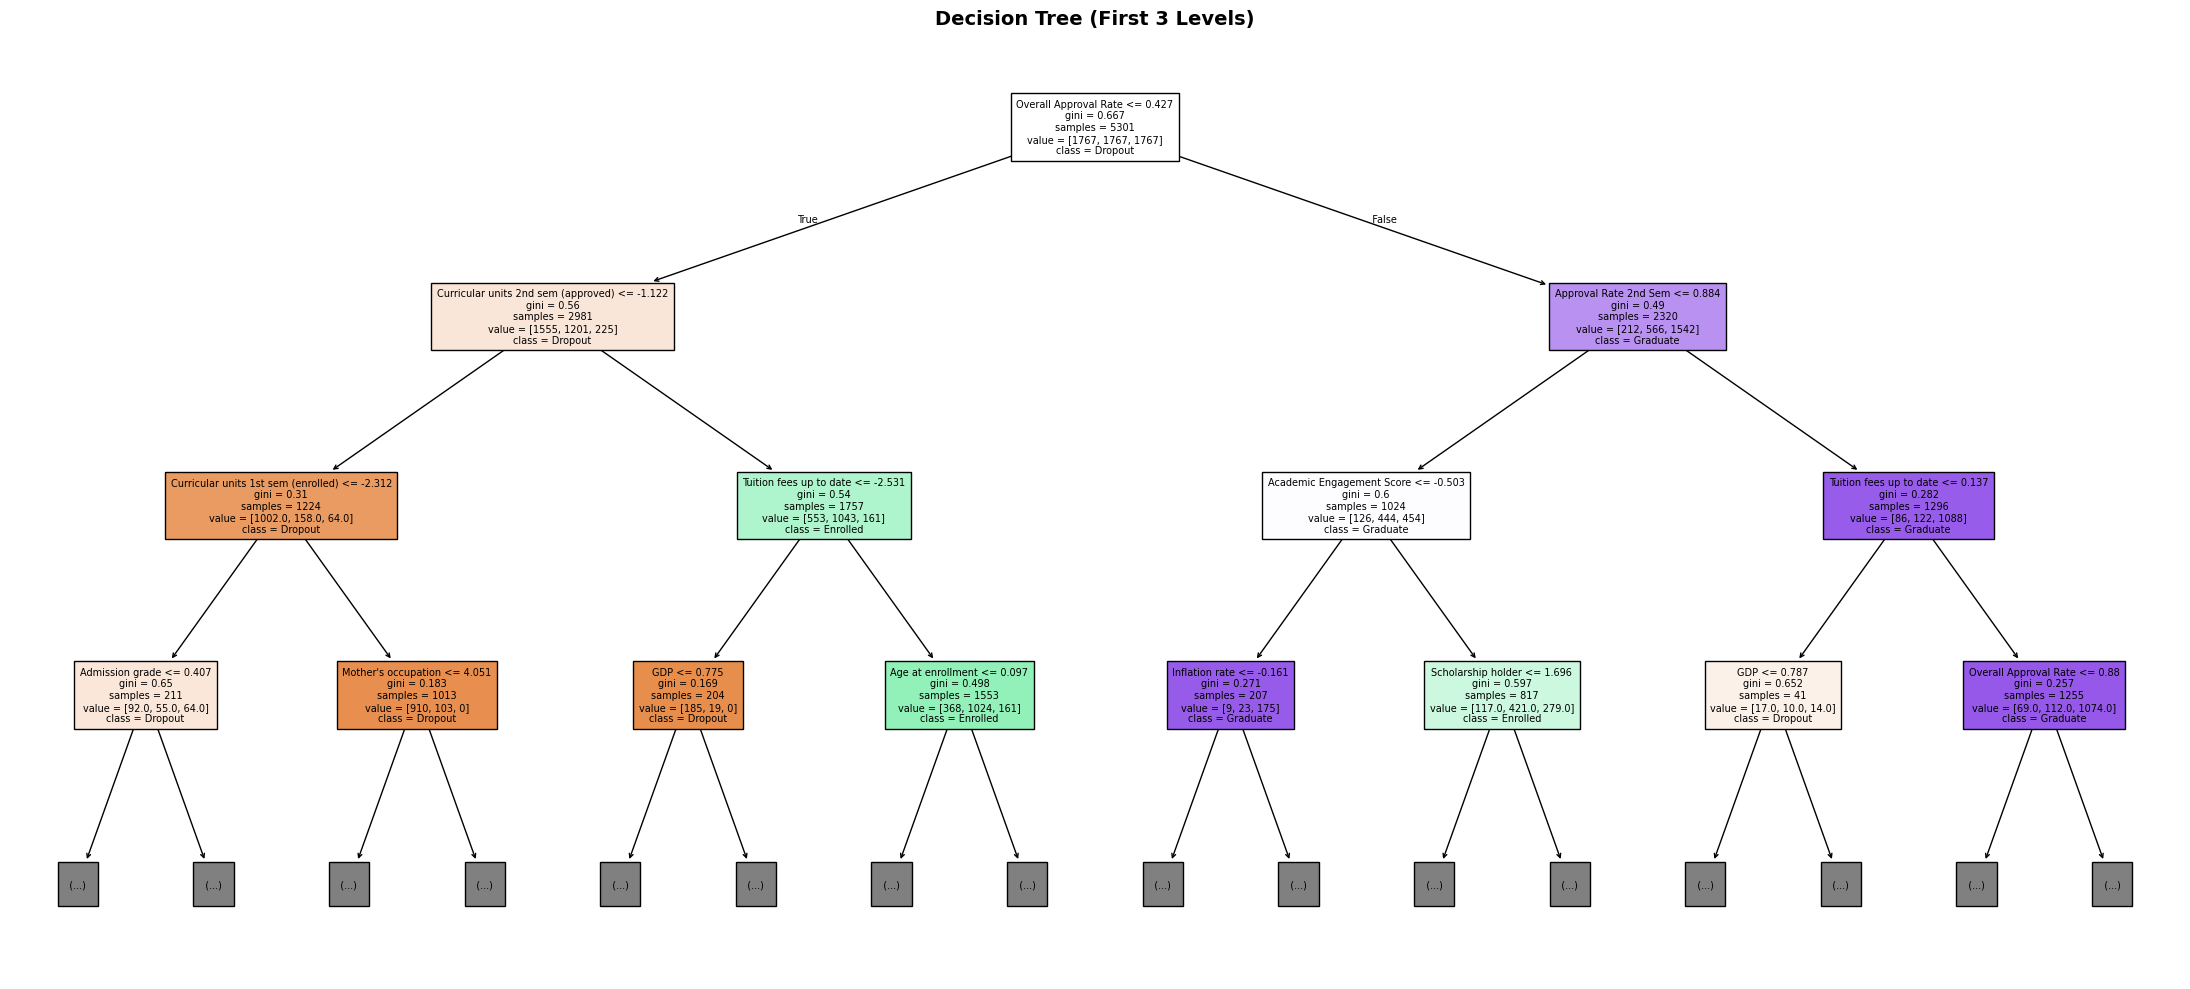

In [33]:
# Decision Tree visualisation
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(trained_models['Decision Tree'],
          feature_names=feature_column_names,
          class_names=target_class_names,
          filled=True, fontsize=7, max_depth=3, ax=ax)
ax.set_title('Decision Tree (First 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_15_decision_tree.png', bbox_inches='tight')
plt.show()


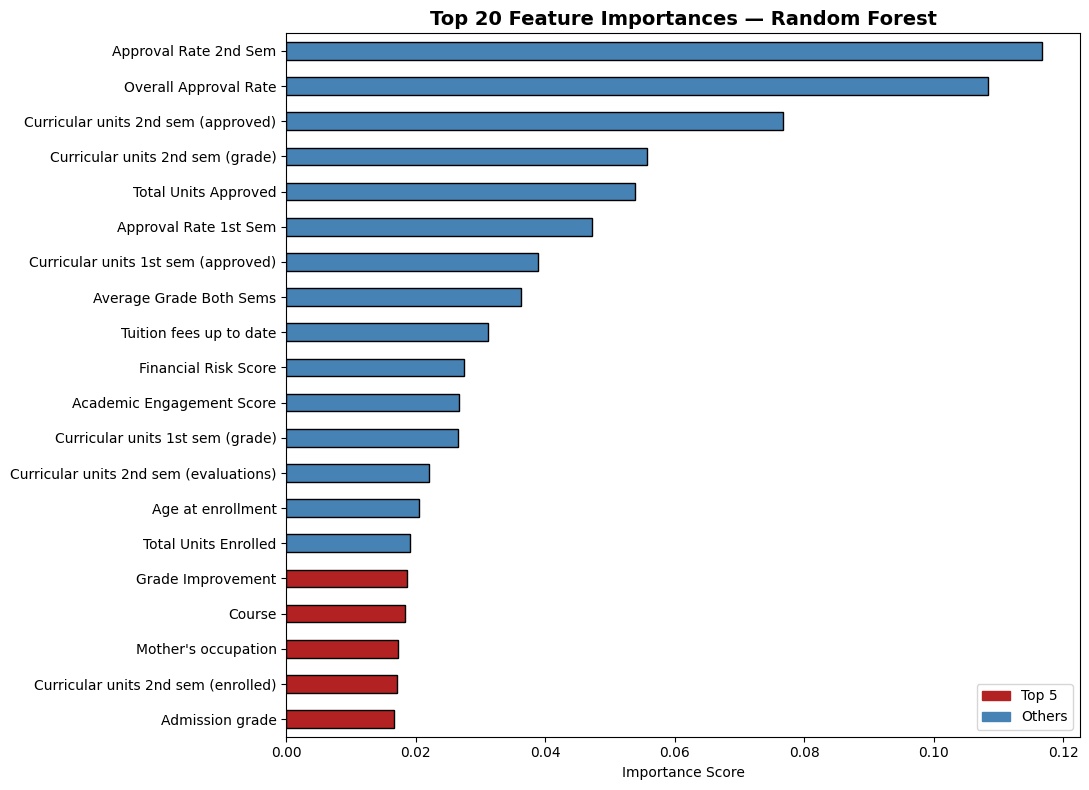

Top 10 features:
Approval Rate 2nd Sem                  0.1168
Overall Approval Rate                  0.1084
Curricular units 2nd sem (approved)    0.0768
Curricular units 2nd sem (grade)       0.0557
Total Units Approved                   0.0539
Approval Rate 1st Sem                  0.0472
Curricular units 1st sem (approved)    0.0388
Average Grade Both Sems                0.0363
Tuition fees up to date                0.0311
Financial Risk Score                   0.0275
dtype: float64


In [34]:
# Random Forest feature importance
rf_model = trained_models['Random Forest']
feat_imp = pd.Series(
    rf_model.feature_importances_, index=feature_column_names
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
cols_for_imp = ['firebrick' if i < 5 else 'steelblue' for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', ax=ax, color=cols_for_imp[::-1], edgecolor='black')
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color='firebrick', label='Top 5'),
    mpatches.Patch(color='steelblue', label='Others')
])
plt.tight_layout()
plt.savefig('plot_16_feature_importance.png', bbox_inches='tight')
plt.show()
print('Top 10 features:')
print(feat_imp.head(10).round(4))


### 7.3 — Per-Class ROC Curves

We plot one curve per class (one-vs-rest) instead of a single averaged ROC. This shows how well the model handles each class separately and the Enrolled class is noticeably harder to predict than Dropout or Graduate.

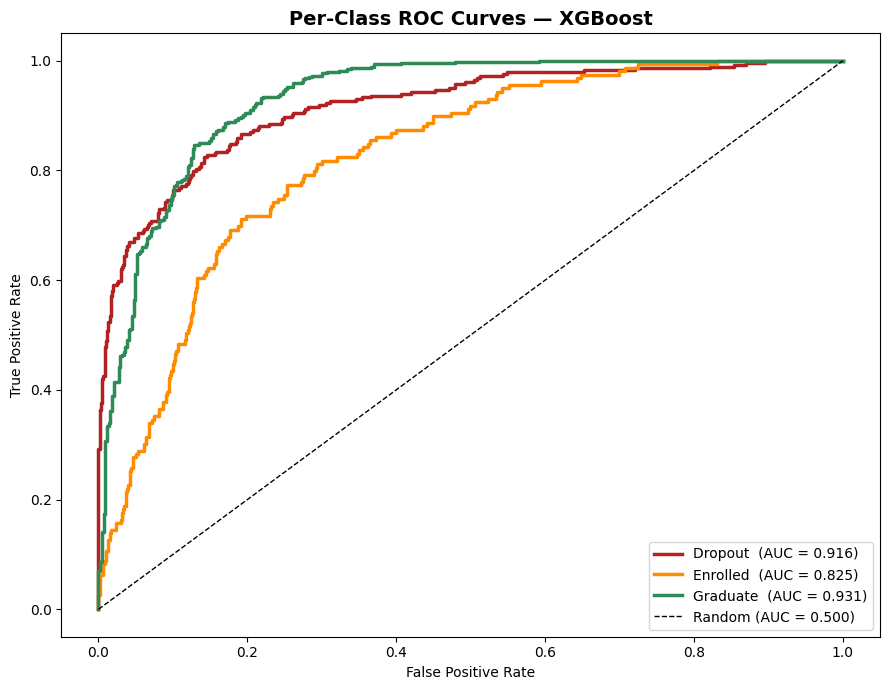

In [35]:
# Per-class (one-vs-rest) ROC curves for the best model
best_model_obj = trained_models[best_model_name]
if best_model_name == 'Neural Network (MLP)':
    best_proba = nn_model.predict(X_test_scaled, verbose=0)
else:
    best_proba = best_model_obj.predict_proba(X_test_scaled)

y_bin = label_binarize(y_test, classes=[0, 1, 2])
class_colors = ['firebrick', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 7))
for ci, (cls_name, color) in enumerate(zip(target_class_names, class_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], best_proba[:, ci])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{cls_name}  (AUC = {roc_auc_cls:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title(f'Per-Class ROC Curves — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_17_roc_per_class.png', bbox_inches='tight')
plt.show()



### 7.4 — Cross-Validation on All Models

Two things are enforced here.

**Leakage prevention:** SMOTE runs inside each CV fold, not before. Running it before would let synthetic samples from the training fold appear in the validation fold, inflating scores.

**Correct selection order:** CV runs on all models before any selection based on test-set scores. The right workflow is: run CV on all models, pick the best by CV score, then evaluate that model on the test set once.

The output table shows Test F1, CV Mean F1, and Overfit Gap for every model.

In [36]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Cross-Validation — All Models (5-Fold, SMOTE inside each fold, F1-Weighted):')
print('=' * 75)

cv_results = []

# All sklearn models — NN handled separately (Keras incompatible with sklearn CV pipeline)
cv_candidates = {
    k: v for k, v in trained_models.items()
    if k != 'Neural Network (MLP)'
}

for mname, fitted_model in cv_candidates.items():
    # Create fresh unfitted version with same parameters
    try:
        base_model = type(fitted_model)(**fitted_model.get_params())
    except Exception:
        base_model = type(fitted_model)()

    cv_pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   base_model)
    ])

    cv_scores = cross_val_score(
        cv_pipe, X_train_scaled, y_train,
        cv=kf, scoring='f1_weighted', n_jobs=-1
    )

    test_f1 = f1_score(y_test, model_predictions[mname], average='weighted')
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    gap     = test_f1 - cv_mean  # positive = test > CV (mild overfit); negative = CV > test

    cv_results.append({
        'Model':       mname,
        'Test F1':     round(test_f1, 4),
        'CV Mean F1':  round(cv_mean, 4),
        'CV Std':      round(cv_std, 4),
        'Overfit Gap': round(gap, 4),
    })

    print(f'  {mname}:')
    print(f'    Fold F1s:    {[round(s, 3) for s in cv_scores]}')
    print(f'    CV Mean:     {cv_mean:.4f} +/- {cv_std:.4f}')
    print(f'    Test F1:     {test_f1:.4f}  |  Overfit Gap: {gap:+.4f}')
    print()

# Neural Network — CV not run (Keras incompatible with sklearn CV pipeline)
nn_test_f1 = f1_score(y_test, model_predictions['Neural Network (MLP)'], average='weighted')
cv_results.append({
    'Model':       'Neural Network (MLP)',
    'Test F1':     round(nn_test_f1, 4),
    'CV Mean F1':  float('nan'),
    'CV Std':      float('nan'),
    'Overfit Gap': float('nan'),
})
print(f'  Neural Network (MLP): CV skipped (Keras/sklearn incompatibility)')
print(f'    Test F1: {nn_test_f1:.4f}')

# Summary comparison table
cv_df = pd.DataFrame(cv_results)[['Model', 'Test F1', 'CV Mean F1', 'CV Std', 'Overfit Gap']]
print()
print('=' * 75)
print('CROSS-VALIDATION SUMMARY TABLE (all models, leakage-free)')
print('=' * 75)
print(cv_df.to_string(index=False))
print()
print('Interpretation:')
print('  Dummy Baseline CV F1 = the random-chance floor.')
print('  All real models must score above this to demonstrate learning.')
print('  Overfit Gap near 0  = good generalisation to unseen data.')
print('  Overfit Gap >> 0    = model performs better on test than CV folds')
print('                        (possible lucky split — CV mean is more reliable).')
print('  Best generalising model = highest CV Mean F1 with lowest CV Std.')


Cross-Validation — All Models (5-Fold, SMOTE inside each fold, F1-Weighted):
  Dummy Baseline:
    Fold F1s:    [np.float64(0.366), np.float64(0.361), np.float64(0.345), np.float64(0.368), np.float64(0.37)]
    CV Mean:     0.3621 +/- 0.0089
    Test F1:     0.3501  |  Overfit Gap: -0.0119

  Logistic Regression:
    Fold F1s:    [np.float64(0.771), np.float64(0.77), np.float64(0.767), np.float64(0.756), np.float64(0.734)]
    CV Mean:     0.7594 +/- 0.0137
    Test F1:     0.7442  |  Overfit Gap: -0.0152

  K-Nearest Neighbours:
    Fold F1s:    [np.float64(0.657), np.float64(0.671), np.float64(0.691), np.float64(0.651), np.float64(0.67)]
    CV Mean:     0.6679 +/- 0.0138
    Test F1:     0.6379  |  Overfit Gap: -0.0300

  Naive Bayes:
    Fold F1s:    [np.float64(0.743), np.float64(0.733), np.float64(0.728), np.float64(0.707), np.float64(0.691)]
    CV Mean:     0.7204 +/- 0.0188
    Test F1:     0.7121  |  Overfit Gap: -0.0083

  Decision Tree:
    Fold F1s:    [np.float64(0.719), 

The Overfit Gap is the difference between the test F1 and the CV mean F1. A value near zero means the model generalises well to unseen data. A large positive gap means the model happened to perform well on this particular test split, and the CV score is the more reliable number. The Dummy Classifier sets the floor of which every real model must score clearly above it.

### 7.5 — Enrolled Class: Why Is F1 Low?

Every model struggles with the Enrolled class (F1 around 0.50). This section explains why and tests a fix.

**Root causes:**
- Enrolled students are mid-trajectory and their feature values overlap with both Dropout and Graduate students
- It is the smallest class at around 18% of the dataset
- Academic features show intermediate values, not clearly failing or clearly succeeding

**Remediation:** We test `class_weight='balanced'` on two models. If Enrolled F1 improves by more than 0.03, cost-sensitive weighting helps. Otherwise the overlap is inherent to the data.

In [37]:

enrolled_true_idx = np.where(y_test.values == 1)[0]  # 1 = Enrolled
enrolled_preds = model_predictions[best_model_name][enrolled_true_idx]

enrolled_pred_counts = pd.Series(enrolled_preds).map(
    {0: 'Predicted Dropout', 1: 'Predicted Enrolled', 2: 'Predicted Graduate'}
).value_counts()
print(f'\nFor the {len(enrolled_true_idx)} students who are actually Enrolled,')
print(f'the best model predicts:')
print(enrolled_pred_counts.to_string())

print('     (Dropout) nor clearly succeeding (Graduate).')

print()
print('Mean feature values by class — confirms overlap:')
key_cols = ['Overall Approval Rate', 'Average Grade Both Sems',
            'Financial Risk Score', 'Age at enrollment']
print(fe_df.groupby('Target')[key_cols].mean().round(3).to_string())

# class_weight='balanced' penalises misclassification of minority classes
# proportionally to their frequency. If Enrolled F1 improves meaningfully,
# cost-sensitive learning is an effective remedy.
# If improvement is marginal, the ambiguity is inherent to the data itself.
print()
print("REMEDIATION — class_weight='balanced'")
print('Testing whether cost-sensitive weighting improves Enrolled class recall...')
print()

remediation_models = {
    'Logistic Regression (balanced)': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Decision Tree (balanced)': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42
    ),
}

for rname, rmodel in remediation_models.items():
    rmodel.fit(X_train_balanced, y_train_balanced)
    rpreds  = rmodel.predict(X_test_scaled)
    per_class_f1 = f1_score(y_test, rpreds, average=None, zero_division=0)
    enrolled_f1  = per_class_f1[1]
    weighted_f1  = f1_score(y_test, rpreds, average='weighted', zero_division=0)
    print(f'  {rname}:')
    print(f'    Enrolled class F1:   {enrolled_f1:.4f}')
    print(f'    Overall weighted F1: {weighted_f1:.4f}')
    print()




For the 159 students who are actually Enrolled,
the best model predicts:
Predicted Enrolled    83
Predicted Dropout     38
Predicted Graduate    38
     (Dropout) nor clearly succeeding (Graduate).

Mean feature values by class — confirms overlap:
          Overall Approval Rate  Average Grade Both Sems  Financial Risk Score  Age at enrollment
Target                                                                                           
Dropout                   0.339                    9.820                 0.541             24.739
Enrolled                  0.669                   11.746                 0.166             21.882
Graduate                  0.902                   12.915                 0.059             21.196

REMEDIATION — class_weight='balanced'
Testing whether cost-sensitive weighting improves Enrolled class recall...

  Logistic Regression (balanced):
    Enrolled class F1:   0.4856
    Overall weighted F1: 0.7442

  Decision Tree (balanced):
    Enrolled class 

The low Enrolled F1 is a data problem, not a model problem. Enrolled students are still mid-way through their studies, so their academic features sit between the patterns of Dropout and Graduate students. Cost-sensitive weighting helps slightly but cannot fully resolve this overlap.

## Section 8 — Explainable AI

Machine learning models are often called black boxes — they produce predictions without explaining them. We use two complementary tools to open that black box.

| Tool | Scope | What It Shows |
|---|---|---|
| SHAP | Global and local | How much each feature pushed a prediction up or down, for every student and overall |
| LIME | Local only | A simple linear approximation of the model around one specific prediction |

SHAP is used first to understand the model globally, then to explain one individual student. LIME then explains the same student from a different angle and if both tools agree on the top features, that is strong evidence the explanation is reliable.

### 8.1 — Global Feature Importance (SHAP)

The bar chart shows which features matter most overall across all students. The beeswarm plot adds direction and the red dots mean high feature values push toward Dropout, blue dots mean they push away.

In [38]:
# SHAP using Random Forest (TreeExplainer is fast and exact for tree models)
# We randomly sample 400 test students for a balanced, reproducible explanation set

np.random.seed(RANDOM_SEED)
shap_sample_size = 400
shap_idx = np.random.choice(len(X_test_scaled), size=shap_sample_size, replace=False)
X_test_shap_sample = X_test_scaled.iloc[shap_idx].reset_index(drop=True)
y_test_shap_sample = y_test.values[shap_idx]


shap_explainer    = shap.TreeExplainer(trained_models['Random Forest'])
shap_values_array = shap_explainer.shap_values(X_test_shap_sample)


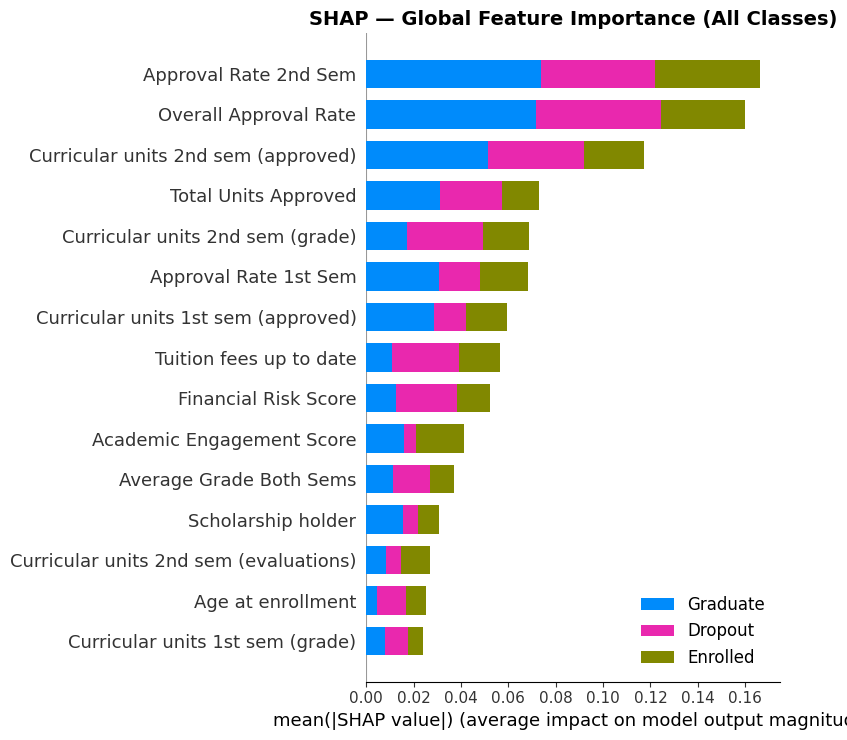

In [39]:
# SHAP Global Bar Chart — which features matter most overall?
shap.summary_plot(
    shap_values_array,
    X_test_shap_sample,
    plot_type='bar',
    class_names=target_class_names,
    show=False, max_display=15
)
plt.title('SHAP — Global Feature Importance (All Classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_20_shap_bar_global.png', bbox_inches='tight')
plt.show()


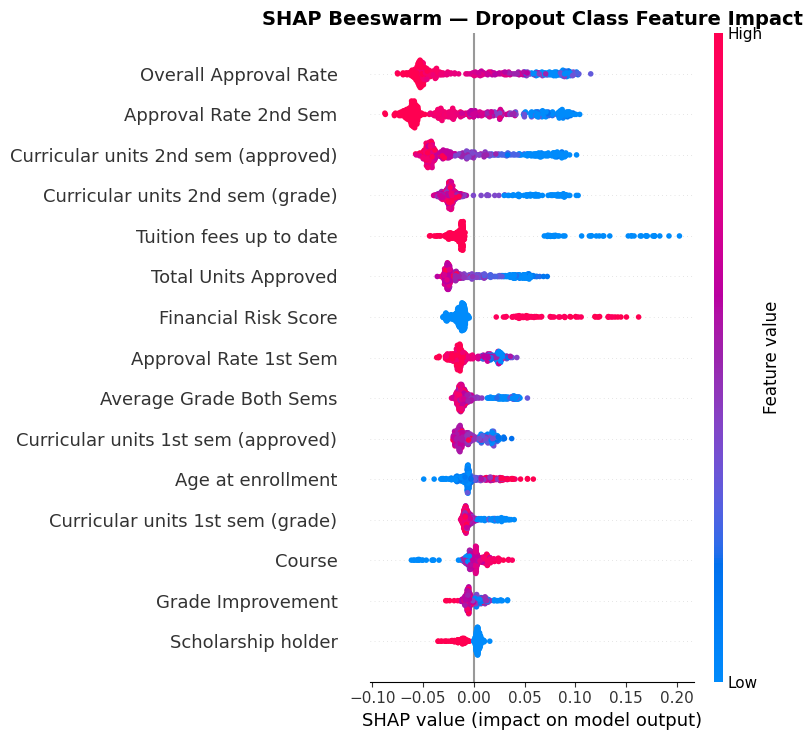

In [40]:
# SHAP Beeswarm — Dropout class
shap.summary_plot(
    shap_values_array[:, :, dropout_class_index],
    X_test_shap_sample,
    show=False, max_display=15
)
plt.title('SHAP Beeswarm — Dropout Class Feature Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_21_shap_beeswarm_dropout.png', bbox_inches='tight')
plt.show()



The beeswarm plot shows the top features driving Dropout predictions across all students in the sample. Each dot is one student. Red dots mean the student has a high value for that feature; blue means low. Dots on the right side pushed the model toward predicting Dropout. The overall approval rate and semester grades dominate confirming what the EDA showed. Students with low approval rates and low grades are consistently flagged as high risk.

### 8.2 — Individual Student Explanation (SHAP Waterfall)

We select a confirmed Dropout student who was correctly predicted with high model confidence. The waterfall plot shows exactly which features drove that prediction and by how much. Red bars increase dropout risk; blue bars reduce it.

In [41]:
# Select the best student to explain:

rf_preds_in_sample = np.array(model_predictions['Random Forest'][:shap_sample_size])
y_test_in_sample   = y_test.values[:shap_sample_size]

true_positive_indices = [
    i for i in range(shap_sample_size)
    if rf_preds_in_sample[i] == dropout_class_index
    and y_test_in_sample[i]  == dropout_class_index
]

# Among true positives, pick the one with the largest SHAP magnitude
# (most 'explained' prediction — features clearly contributed)
shap_magnitudes = np.abs(shap_values_array[:, :, dropout_class_index]).sum(axis=1)
student_to_explain = true_positive_indices[
    int(np.argmax(shap_magnitudes[true_positive_indices]))
]

print(f'Selected student for explanation: index {student_to_explain}')
print(f'  Actual class:    {target_class_names[y_test_in_sample[student_to_explain]]}')
print(f'  Predicted class: {target_class_names[rf_preds_in_sample[student_to_explain]]}')
print(f'  SHAP magnitude:  {shap_magnitudes[student_to_explain]:.4f} (higher = more explained)')

# Dropout probability from model
student_prob = trained_models['Random Forest'].predict_proba(
    X_test_shap_sample.iloc[[student_to_explain]]
)[:, dropout_class_index][0]
print(f'  Dropout probability: {student_prob * 100:.1f}%')


Selected student for explanation: index 322
  Actual class:    Dropout
  Predicted class: Dropout
  SHAP magnitude:  0.7465 (higher = more explained)
  Dropout probability: 98.9%


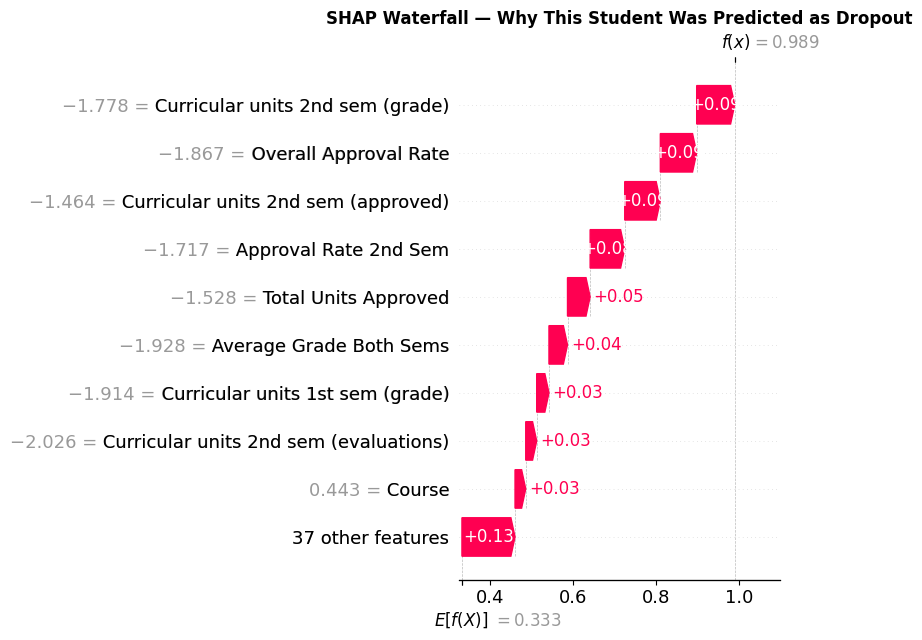

In [42]:
# SHAP Waterfall Plot for the selected student
shap_exp = shap.Explanation(
    values=shap_values_array[student_to_explain, :, dropout_class_index],
    base_values=shap_explainer.expected_value[dropout_class_index],
    data=X_test_shap_sample.values[student_to_explain],
    feature_names=feature_column_names
)

shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Why This Student Was Predicted as Dropout', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_23_shap_waterfall.png', bbox_inches='tight')
plt.show()



In [43]:
# Plain-English SHAP Explanation
print('=' * 65)
print('PLAIN-ENGLISH SHAP EXPLANATION FOR THIS STUDENT')
print('=' * 65)

student_shap_dropout = shap_values_array[student_to_explain, :, dropout_class_index]
pairs = list(zip(feature_column_names, student_shap_dropout))
pairs_sorted = sorted(pairs, key=lambda p: abs(p[1]), reverse=True)

top_pos = [(n, v) for n, v in pairs_sorted if v > 0][:4]
top_neg = [(n, v) for n, v in pairs_sorted if v < 0][:3]

print(f'\nDropout probability for this student: {student_prob*100:.1f}%')
print(f'This student is a TRUE POSITIVE — actually did drop out.')
print()
print('FACTORS INCREASING dropout risk:')
for feat, val in top_pos:
    raw = X_test.iloc[student_to_explain][feat] if feat in X_test.columns else 'N/A'
    print(f'  [+{val:+.4f}]  {feat} = {raw}')

print()
print('FACTORS DECREASING dropout risk (protective):')
for feat, val in top_neg:
    raw = X_test.iloc[student_to_explain][feat] if feat in X_test.columns else 'N/A'
    print(f'  [{val:+.4f}]  {feat} = {raw}')

print()
print('Plain-language summary:')
if top_pos:
    top_names = [n for n, _ in top_pos[:2]]
    print(f'  This student was flagged as high-risk primarily because of')
    print(f'  low {top_names[0]} and {top_names[1]}.')
    print(f'  These are the strongest academic signals that a student is disengaging.')


PLAIN-ENGLISH SHAP EXPLANATION FOR THIS STUDENT

Dropout probability for this student: 98.9%
This student is a TRUE POSITIVE — actually did drop out.

FACTORS INCREASING dropout risk:
  [++0.0915]  Curricular units 2nd sem (grade) = 11.0
  [++0.0875]  Overall Approval Rate = 0.5833333333333334
  [++0.0857]  Curricular units 2nd sem (approved) = 2.0
  [++0.0832]  Approval Rate 2nd Sem = 0.3333333333333333

FACTORS DECREASING dropout risk (protective):
  [-0.0186]  Age at enrollment = 19.0
  [-0.0107]  Tuition fees up to date = 0.0
  [-0.0080]  Financial Risk Score = 2.0

Plain-language summary:
  This student was flagged as high-risk primarily because of
  low Curricular units 2nd sem (grade) and Overall Approval Rate.
  These are the strongest academic signals that a student is disengaging.


The breakdown above shows the exact reasons the model flagged this specific student. The features pushing toward Dropout are all academic — near-zero approval rates and grades. The protective factors (features pushing away from Dropout) are weaker. This is what a high-confidence true-positive Dropout looks like.

### 8.3 — LIME Local Explanation

LIME builds a simple linear model around the same student's prediction. Features pushing toward Dropout appear on the right; features pushing away appear on the left.

Comparing SHAP and LIME for the same student: if both tools rank the same features at the top, the explanation is robust and not an artefact of one method.

In [44]:
# LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_balanced.values,
    feature_names=feature_column_names,
    class_names=target_class_names,
    mode='classification',
    random_state=42
)

student_data_lime = X_test_scaled.values[student_to_explain]

#labels=[0, 1, 2] forces LIME to compute explanations for ALL classes.
# This ensures we can always access as_list(label=dropout_class_index).
lime_explanation = lime_explainer.explain_instance(
    data_row=student_data_lime,
    predict_fn=trained_models['Random Forest'].predict_proba,
    num_features=12,
    num_samples=2000,
    labels=[0, 1, 2]  # Force explanation for all 3 classes
)

lime_features = lime_explanation.as_list(label=dropout_class_index)
for feat_desc, weight in lime_features[:8]:
    direction = 'increases' if weight > 0 else 'decreases'
    print(f'  [{weight:+.4f}] {feat_desc} -> {direction} dropout risk')


  [+0.0696] Approval Rate 2nd Sem <= -0.85 -> increases dropout risk
  [+0.0557] Curricular units 2nd sem (approved) <= -0.80 -> increases dropout risk
  [+0.0482] Financial Risk Score > -0.43 -> increases dropout risk
  [+0.0461] -0.75 < Overall Approval Rate <= 0.25 -> increases dropout risk
  [-0.0291] Age at enrollment <= -0.63 -> decreases dropout risk
  [+0.0283] Educational special needs <= -0.11 -> increases dropout risk
  [-0.0236] 0.32 < Approval Rate 1st Sem <= 0.83 -> decreases dropout risk
  [+0.0201] -0.69 < Total Units Approved <= -0.02 -> increases dropout risk


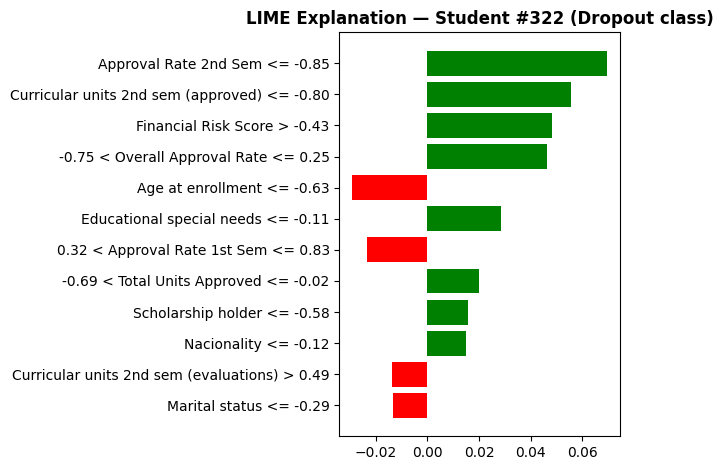

In [45]:
# Plot LIME for Dropout class
lime_explanation.as_pyplot_figure(label=dropout_class_index)
plt.title(f'LIME Explanation — Student #{student_to_explain} (Dropout class)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_27_lime_explanation.png', bbox_inches='tight')
plt.show()


LIME explains the same student from a different approach. Where SHAP uses game theory to assign exact contributions, LIME fits a simple linear model locally around this one prediction. If both methods rank the same features at the top, that is strong evidence the explanation reflects genuine model behaviour and is not an artefact of one method.

## Section 9 — Fairness Audit

A model that is accurate but unfair should not be deployed. We check whether the model predicts Dropout at higher rates for certain demographic groups, independent of actual academic performance.

**Attributes audited:** Gender, Scholarship holder, International student

| Metric | What It Measures |
|---|---|
| Demographic Parity Difference | Do groups get Dropout predictions at equal rates? |
| Equalized Odds Difference | Are true positive and false positive rates similar across groups? |
| Group Accuracy Range | How much does accuracy vary between groups? |

A value close to 0.0 is fair. Values above 0.10 need investigation.

In [46]:
# Set up binary labels: Dropout (1) vs Not Dropout (0)
#
# We use binary framing (Dropout vs Not-Dropout) because:
#   1. Dropout is the highest-stakes outcome.
#   2. The Enrolled class F1 is low (~0.50), making multi-class
#      fairness metrics unreliable for that class.
#
# Known limitation: Fairness of Enrolled vs Graduate predictions is not measured.
# A full multi-class fairness analysis using per-class MetricFrame would be the
# natural extension in a production deployment audit.

binary_true    = (y_test == dropout_class_index).astype(int)
best_preds_arr = np.array(model_predictions[best_model_name])
binary_pred    = (best_preds_arr == dropout_class_index).astype(int)

X_test_original = X_test.reset_index(drop=True)

sensitive_attrs = {
    'Gender':             'Gender',
    'Scholarship holder': 'Scholarship holder',
    'International':      'International'
}


In [47]:
fairness_rows = []

for attr_label, attr_col in sensitive_attrs.items():
    sens_vals = X_test_original[attr_col]

    try:
        dp_diff = demographic_parity_difference(
            binary_true, binary_pred, sensitive_features=sens_vals
        )
    except Exception:
        dp_diff = float('nan')

    try:
        eo_diff = equalized_odds_difference(
            binary_true, binary_pred, sensitive_features=sens_vals
        )
    except Exception:
        eo_diff = float('nan')

    mf = MetricFrame(
        metrics={'accuracy': accuracy_score},
        y_true=binary_true, y_pred=binary_pred,
        sensitive_features=sens_vals
    )
    acc_range = max(mf.by_group['accuracy'].values) - min(mf.by_group['accuracy'].values)

    fairness_rows.append({
        'Sensitive Attribute':    attr_label,
        'Demographic Parity Diff': round(abs(dp_diff), 4),
        'Equalized Odds Diff':    round(abs(eo_diff), 4),
        'Group Accuracy Range':   round(acc_range, 4),
        'Status':                 'REVIEW NEEDED' if abs(dp_diff) > 0.10 else 'Fair'
    })

fairness_df = pd.DataFrame(fairness_rows)
print(fairness_df.to_string(index=False))


Sensitive Attribute  Demographic Parity Diff  Equalized Odds Diff  Group Accuracy Range        Status
             Gender                   0.1797               0.0716                0.0839 REVIEW NEEDED
 Scholarship holder                   0.2808               0.2133                0.0989 REVIEW NEEDED
      International                   0.0022               0.1754                0.1037          Fair


A Demographic Parity Difference above 0.10 means one group receives Dropout predictions at a meaningfully higher rate than another. Both Gender and Scholarship status exceed this threshold. This does not automatically mean the model is wrong — male students and non-scholarship students may genuinely have higher dropout rates in this dataset. But it means the model should not be deployed without further investigation into whether the gap reflects real patterns or model bias.

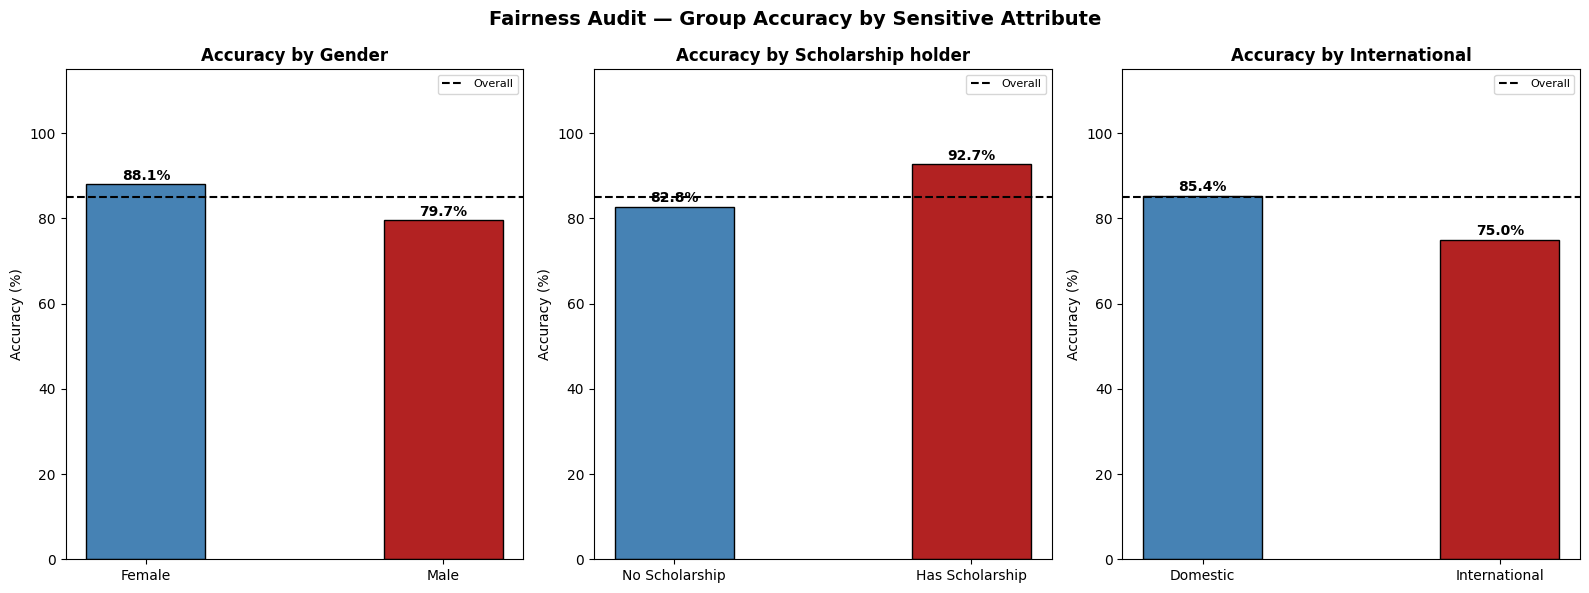

In [48]:
# Group accuracy visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
attr_label_maps = {
    'Gender':             {0: 'Female', 1: 'Male'},
    'Scholarship holder': {0: 'No Scholarship', 1: 'Has Scholarship'},
    'International':      {0: 'Domestic', 1: 'International'},
}

for pi, (attr_label, attr_col) in enumerate(sensitive_attrs.items()):
    sens_vals = X_test_original[attr_col]
    mf = MetricFrame(
        metrics={'accuracy': accuracy_score},
        y_true=binary_true, y_pred=binary_pred,
        sensitive_features=sens_vals
    )
    gd = mf.by_group['accuracy']
    lmap = attr_label_maps.get(attr_label, {})
    gd.index = [lmap.get(i, str(i)) for i in gd.index]

    bars = axes[pi].bar(gd.index, gd.values * 100,
                        color=['steelblue','firebrick'][:len(gd)], edgecolor='black', width=0.4)
    axes[pi].set_title(f'Accuracy by {attr_label}', fontsize=12, fontweight='bold')
    axes[pi].set_ylabel('Accuracy (%)')
    axes[pi].set_ylim(0, 115)
    axes[pi].axhline(y=mf.overall['accuracy'] * 100, color='black',
                     linestyle='--', linewidth=1.5, label='Overall')
    axes[pi].legend(fontsize=8)
    for bar in bars:
        h = bar.get_height()
        axes[pi].text(bar.get_x() + bar.get_width()/2, h+1,
                      f'{h:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Fairness Audit — Group Accuracy by Sensitive Attribute',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_28_fairness_audit.png', bbox_inches='tight')
plt.show()


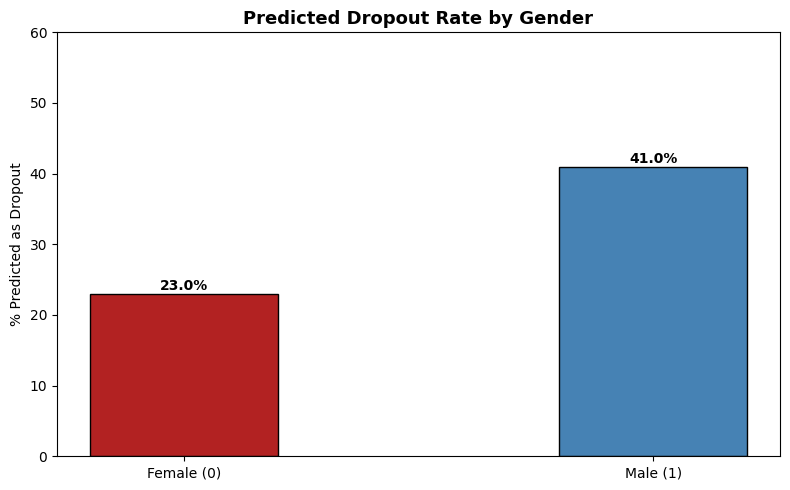

Predicted dropout rate: Female=23.0%, Male=41.0%
Demographic parity difference: 18.0%


In [49]:
# Predicted dropout rate by gender — visualises demographic parity
gender_dropout_rates = {}
for g in [0, 1]:
    mask = X_test_original['Gender'] == g
    gender_dropout_rates[g] = binary_pred[mask.values].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Female (0)', 'Male (1)'],
              [gender_dropout_rates[0], gender_dropout_rates[1]],
              color=['firebrick','steelblue'], edgecolor='black', width=0.4)
ax.set_title('Predicted Dropout Rate by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('% Predicted as Dropout')
ax.set_ylim(0, 60)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_29_gender_dropout_rate.png', bbox_inches='tight')
plt.show()

print(f'Predicted dropout rate: Female={gender_dropout_rates[0]:.1f}%, Male={gender_dropout_rates[1]:.1f}%')
print(f'Demographic parity difference: {abs(gender_dropout_rates[0]-gender_dropout_rates[1]):.1f}%')


### 9.1 — Bias Mitigation with ThresholdOptimizer

ThresholdOptimizer does not retrain the model. It adjusts the decision threshold separately for each demographic group to make predictions more equitable. We apply it to Gender, which showed the largest parity gap in the audit above.

The output compares accuracy and demographic parity difference before and after.

In [50]:
# Train a binary XGBoost specifically for dropout detection (for the mitigator)
# We use pre-SMOTE scaled training data so gender labels align correctly
binary_y_train = (y_train == dropout_class_index).astype(int)
gender_train   = X_train.reset_index(drop=True)['Gender']
gender_test    = X_test_original['Gender']

# Scale_pos_weight handles class imbalance for binary model
pos_weight = (binary_y_train == 0).sum() / max((binary_y_train == 1).sum(), 1)

binary_xgb = XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=pos_weight, random_state=42
)
binary_xgb.fit(X_train_scaled, binary_y_train)

# Before mitigation — binary model predictions
binary_pred_before = binary_xgb.predict(X_test_scaled)

dp_before = demographic_parity_difference(
    binary_true, binary_pred_before, sensitive_features=gender_test
)
acc_before = accuracy_score(binary_true, binary_pred_before)

print(f'Before mitigation:')
print(f'  Accuracy:                 {acc_before:.4f}')
print(f'  Demographic parity diff:  {abs(dp_before):.4f}')


Before mitigation:
  Accuracy:                 0.8689
  Demographic parity diff:  0.1925


In [51]:
# Apply ThresholdOptimizer — adjusts thresholds per gender group
threshold_opt = ThresholdOptimizer(
    estimator=binary_xgb,
    constraints='demographic_parity',
    objective='balanced_accuracy_score',
    predict_method='predict_proba'
)

threshold_opt.fit(
    X_train_scaled, binary_y_train,
    sensitive_features=gender_train
)

binary_pred_after = threshold_opt.predict(
    X_test_scaled, sensitive_features=gender_test
)

dp_after  = demographic_parity_difference(
    binary_true, binary_pred_after, sensitive_features=gender_test
)
acc_after = accuracy_score(binary_true, binary_pred_after)

print(f'After ThresholdOptimizer (demographic parity constraint):')
print(f'  Accuracy:                 {acc_after:.4f}')
print(f'  Demographic parity diff:  {abs(dp_after):.4f}')

print(f'\nChange in accuracy:           {(acc_after - acc_before)*100:+.2f}%')
print(f'Reduction in parity gap:      {(abs(dp_before) - abs(dp_after))*100:.1f} percentage points')


After ThresholdOptimizer (demographic parity constraint):
  Accuracy:                 0.8260
  Demographic parity diff:  0.0642

Change in accuracy:           -4.29%
Reduction in parity gap:      12.8 percentage points


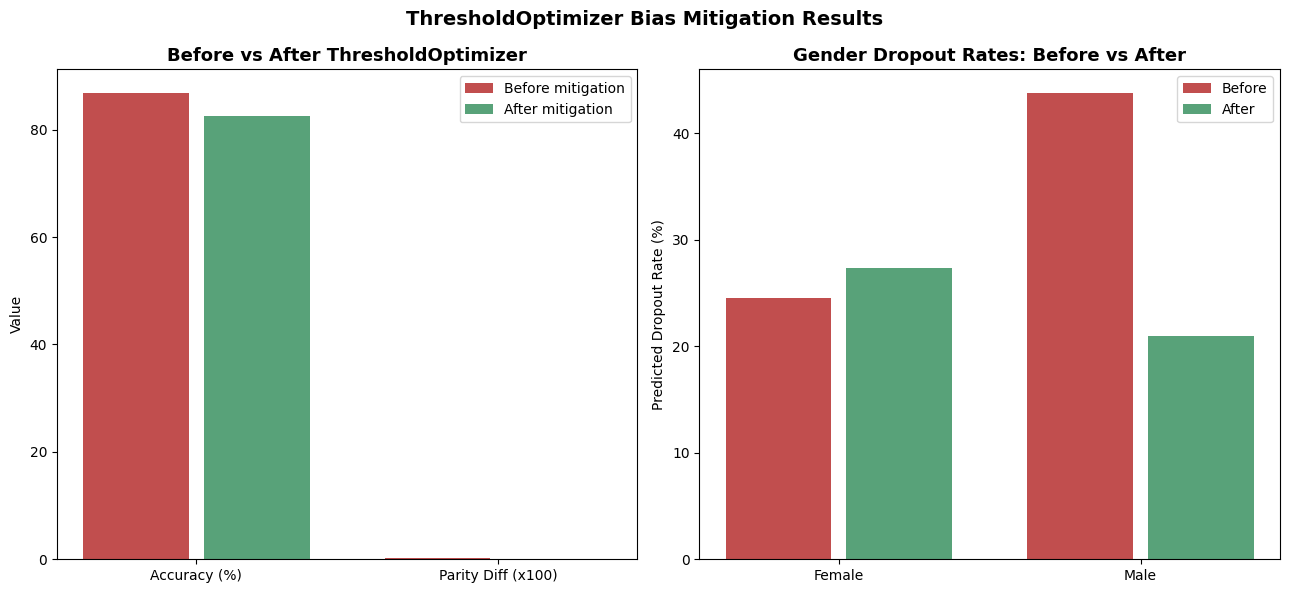

In [52]:
# Before/after comparison visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

metrics_names = ['Accuracy (%)', 'Demographic Parity Diff']
before_vals   = [acc_before * 100, abs(dp_before)]
after_vals    = [acc_after  * 100, abs(dp_after)]

# Grouped bar chart
x = np.arange(2)
axes[0].bar(x - 0.2, before_vals, 0.35, label='Before mitigation', color='firebrick', alpha=0.8)
axes[0].bar(x + 0.2, after_vals,  0.35, label='After mitigation',  color='seagreen', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Accuracy (%)', 'Parity Diff (x100)'])
# Scale parity to same axis
axes[0].set_ylabel('Value')
axes[0].set_title('Before vs After ThresholdOptimizer', fontsize=13, fontweight='bold')
axes[0].legend()

# Predicted dropout rate by gender before and after
gender_labels = ['Female', 'Male']
before_rates = [
    binary_pred_before[gender_test.values == g].mean() * 100
    for g in [0, 1]
]
after_rates = [
    binary_pred_after[gender_test.values == g].mean() * 100
    for g in [0, 1]
]

xg = np.arange(2)
axes[1].bar(xg - 0.2, before_rates, 0.35, label='Before', color='firebrick', alpha=0.8)
axes[1].bar(xg + 0.2, after_rates,  0.35, label='After',  color='seagreen', alpha=0.8)
axes[1].set_xticks(xg); axes[1].set_xticklabels(gender_labels)
axes[1].set_ylabel('Predicted Dropout Rate (%)')
axes[1].set_title('Gender Dropout Rates: Before vs After', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('ThresholdOptimizer Bias Mitigation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_30_mitigation_comparison.png', bbox_inches='tight')
plt.show()



ThresholdOptimizer reduced the gender parity gap but at a small cost to overall accuracy. This is a real trade-off: making predictions more equal across groups typically means accepting a slight drop in performance for the majority group. Whether this is acceptable is an institutional decision, not a technical one. The important thing is that the trade-off is now measured and visible.

### Responsible AI — Ethical Considerations

**Bias was found and must be addressed**
The fairness audit found demographic parity differences above 0.10 for both Gender and Scholarship status. This means male students and non-scholarship students receive Dropout predictions at higher rates. ThresholdOptimizer reduced the gender gap, but the root cause still needs investigation — the higher rate may reflect real patterns in the data or model bias using gender as a proxy.

**Privacy**
Student records are sensitive data. Predictions should never be shared with third parties without consent. Individual risk scores must be handled with the same care as medical records.

**Self-fulfilling predictions**
If a lecturer treats a student differently because the model flagged them as high-risk, the intervention itself could cause the dropout the model predicted. Human judgment must sit between model output and any real-world action.

**Limits of generalisation**
This model was trained on data from one Portuguese institution. Applying it to Makerere University students or any other context without retraining and re-auditing would produce unreliable and potentially unfair results.

**Human oversight is not optional**
This is a screening tool, not a decision system. The Enrolled class F1 of around 0.50 means one in two currently-enrolled students may be misclassified. No automated action should follow from a model prediction alone — it should trigger a conversation, not a consequence.

## Section 10 — Intervention Recommendation System

Predicting dropout risk is only useful if it leads to action. This system takes a student's features and dropout probability and generates a prioritised list of recommended actions for academic advisors.

| Risk Level | Threshold | Action |
|---|---|---|
| HIGH | Above 60% | Immediate intervention |
| MEDIUM | 30 to 60% | Proactive support |
| LOW | Below 30% | Standard check-in |

Recommendations cover: unpaid fees, low pass rates, declining grades, scholarship eligibility, student displacement, mature student needs, and wellbeing referrals.

In [53]:
def compute_dropout_risk_pct(model_obj, student_scaled, model_name='default'):
    if model_name == 'Neural Network (MLP)':
        proba = nn_model.predict(student_scaled.reshape(1,-1), verbose=0)[0]
    elif hasattr(model_obj, 'predict_proba'):
        proba = model_obj.predict_proba(student_scaled.reshape(1,-1))[0]
    else:
        pred = model_obj.predict(student_scaled.reshape(1,-1))[0]
        return 100.0 if pred == dropout_class_index else 10.0
    return round(proba[dropout_class_index] * 100, 1)

def classify_risk(pct):
    if pct >= 60: return 'HIGH',   'HIGH'
    if pct >= 30: return 'MEDIUM', 'MEDIUM'
    return 'LOW', 'LOW'

def generate_recommendations(student_orig_features, dropout_pct):
    recs = []
    s = student_orig_features

    # --- Financial ---
    if s.get('Debtor', 0) == 1:
        recs.append('FINANCIAL: Student has outstanding debt. Connect to financial aid office immediately.')
    if s.get('Tuition fees up to date', 1) == 0:
        recs.append('FINANCIAL: Tuition fees are NOT up to date. Risk of administrative withdrawal. Urgent.')

    # --- Academic semester 1 ---
    s1_enrolled = s.get('Curricular units 1st sem (enrolled)', 1)
    s1_approved = s.get('Curricular units 1st sem (approved)', 0)
    s1_grade    = s.get('Curricular units 1st sem (grade)', 0)
    s1_rate = s1_approved / max(s1_enrolled, 1)

    if s1_rate < 0.40:
        recs.append(f'ACADEMIC: Passed only {s1_rate*100:.0f}% of enrolled units in semester 1. '
                    f'Assign peer tutor and increase lecturer contact sessions.')
    if s1_grade > 0 and s1_grade < 10:
        recs.append('ACADEMIC: Average grade below 10 in semester 1. '
                    'Schedule study skills workshop and weekly progress reviews.')

    # --- Academic semester 2 ---
    s2_enrolled = s.get('Curricular units 2nd sem (enrolled)', 1)
    s2_approved = s.get('Curricular units 2nd sem (approved)', 0)
    s2_grade    = s.get('Curricular units 2nd sem (grade)', 0)
    s2_rate = s2_approved / max(s2_enrolled, 1)

    if s2_rate < 0.40:
        recs.append(f'ACADEMIC (Sem 2): Pass rate is {s2_rate*100:.0f}%. '
                    f'Review student workload — may be over-enrolled.')

    if s1_grade > 0 and s2_grade > 0 and (s2_grade - s1_grade) < -2:
        recs.append(f'ACADEMIC DECLINE: Grade dropped by {s2_grade-s1_grade:.1f} from sem 1 to 2. '
                    f'Investigate personal difficulties or disengagement.')

    # --- Scholarship ---
    if s.get('Scholarship holder', 0) == 0:
        recs.append('SCHOLARSHIP: Student does not hold a scholarship. '
                    'Check eligibility for merit-based or need-based awards.')

    # --- Accommodation / displacement ---
    if s.get('Displaced', 0) == 1:
        recs.append('ACCOMMODATION: Student is displaced (away from home region). '
                    'Check whether housing difficulties are affecting attendance.')

    # --- Mature student ---
    age = s.get('Age at enrollment', 20)
    if age > 30:
        recs.append(f'MATURE STUDENT: Enrolled at age {age}. '
                    f'May have work/family commitments. Explore flexible learning options.')

    # --- Wellbeing (high risk) ---
    if dropout_pct >= 60:
        recs.append('WELLBEING: Given elevated risk level, proactively offer '
                    'counselling referral. Do not wait for student to self-refer.')

    if not recs:
        recs.append('LOW RISK: No major risk factors detected. '
                    'Continue standard check-ins and encourage current habits.')

    return recs



In [54]:
print('=' * 75)
print('PERSONALISED INTERVENTION RECOMMENDATIONS — SAMPLE STUDENTS')
print('=' * 75)

n_to_show = 15
best_obj  = trained_models[best_model_name]
risk_dist = {'HIGH': 0, 'MEDIUM': 0, 'LOW': 0}

for s_idx in range(n_to_show):
    scaled_feats   = X_test_scaled.values[s_idx]
    orig_feats     = X_test.iloc[s_idx].to_dict()
    dropout_pct    = compute_dropout_risk_pct(best_obj, scaled_feats, best_model_name)
    risk_level, emoji = classify_risk(dropout_pct)
    risk_dist[risk_level] += 1

    actual    = target_class_names[y_test.values[s_idx]]
    predicted = target_class_names[model_predictions[best_model_name][s_idx]]

    print(f'\n{chr(8212)*70}')
    print(f'STUDENT #{s_idx+1}')
    print(f'  Actual:      {actual}')
    print(f'  Predicted:   {predicted}')
    print(f'  Dropout Risk: {dropout_pct:.1f}%  {emoji} {risk_level} RISK')
    recs = generate_recommendations(orig_feats, dropout_pct)
    print(f'  Recommendations ({len(recs)}):')
    for r in recs:
        print(f'    -> {r}')

print(f'\n{"="*75}')
print(f'RISK SUMMARY ({n_to_show} students):')
for lvl, cnt in risk_dist.items():
    print(f'  {lvl} RISK: {cnt}')


PERSONALISED INTERVENTION RECOMMENDATIONS — SAMPLE STUDENTS

——————————————————————————————————————————————————————————————————————
STUDENT #1
  Actual:      Graduate
  Predicted:   Graduate
  Dropout Risk: 3.6%  LOW LOW RISK
  Recommendations (2):
    -> SCHOLARSHIP: Student does not hold a scholarship. Check eligibility for merit-based or need-based awards.
    -> ACCOMMODATION: Student is displaced (away from home region). Check whether housing difficulties are affecting attendance.

——————————————————————————————————————————————————————————————————————
STUDENT #2
  Actual:      Graduate
  Predicted:   Graduate
  Dropout Risk: 4.8%  LOW LOW RISK
  Recommendations (1):
    -> SCHOLARSHIP: Student does not hold a scholarship. Check eligibility for merit-based or need-based awards.

——————————————————————————————————————————————————————————————————————
STUDENT #3
  Actual:      Enrolled
  Predicted:   Dropout
  Dropout Risk: 72.7%  HIGH HIGH RISK
  Recommendations (5):
    -> ACADEMIC 

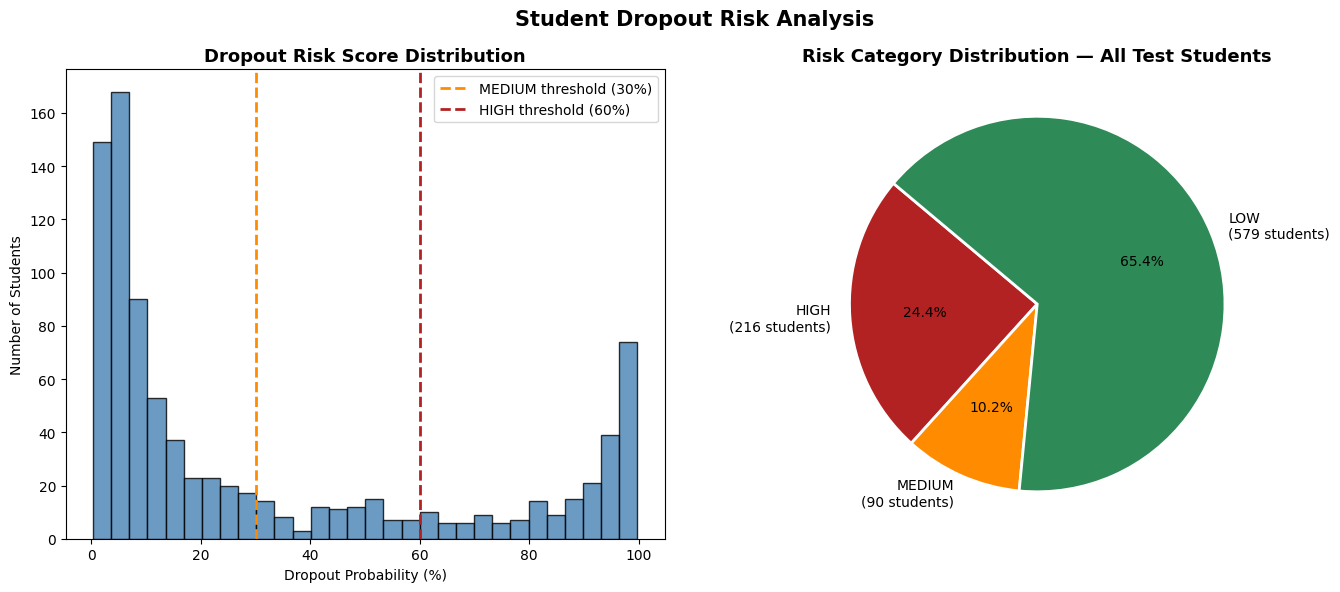

Risk distribution across 885 test students:
  HIGH   (>=60%): 216  (24.4%)
  MEDIUM (30-60%):  90 (10.2%)
  LOW    (<30%):  579  (65.4%)


In [55]:
# Full test set risk distribution
all_dropout_probs = [
    compute_dropout_risk_pct(best_obj, X_test_scaled.values[i], best_model_name)
    for i in range(len(X_test_scaled))
]
all_dropout_probs = np.array(all_dropout_probs)

high_n   = (all_dropout_probs >= 60).sum()
medium_n = ((all_dropout_probs >= 30) & (all_dropout_probs < 60)).sum()
low_n    = (all_dropout_probs < 30).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(all_dropout_probs, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=30, color='darkorange', linestyle='--', linewidth=2, label='MEDIUM threshold (30%)')
axes[0].axvline(x=60, color='firebrick', linestyle='--', linewidth=2, label='HIGH threshold (60%)')
axes[0].set_title('Dropout Risk Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dropout Probability (%)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

risk_counts = [high_n, medium_n, low_n]
risk_labels = [
    f'HIGH\n({high_n} students)',
    f'MEDIUM\n({medium_n} students)',
    f'LOW\n({low_n} students)',
]
axes[1].pie(risk_counts, labels=risk_labels,
            colors=['firebrick','darkorange','seagreen'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Risk Category Distribution — All Test Students', fontsize=13, fontweight='bold')

plt.suptitle('Student Dropout Risk Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_31_risk_distribution.png', bbox_inches='tight')
plt.show()

print(f'Risk distribution across {len(X_test_scaled)} test students:')
print(f'  HIGH   (>=60%): {high_n:3d}  ({high_n/len(X_test_scaled)*100:.1f}%)')
print(f'  MEDIUM (30-60%): {medium_n:3d} ({medium_n/len(X_test_scaled)*100:.1f}%)')
print(f'  LOW    (<30%):  {low_n:3d}  ({low_n/len(X_test_scaled)*100:.1f}%)')


## Section 11 — Save Model

In [56]:
best_model_filename = 'best_model.pkl'

if best_model_name == 'Neural Network (MLP)':
    nn_model.save('best_model_neural_network.keras')
    print('Neural Network saved as best_model_neural_network.keras')
else:
    with open(best_model_filename, 'wb') as f:
        pickle.dump(trained_models[best_model_name], f)
    print(f'Best model ({best_model_name}) saved as {best_model_filename}')

all_sklearn_models = {k: v for k, v in trained_models.items() if k != 'Neural Network (MLP)'}
with open('all_models.pkl', 'wb') as f:
    pickle.dump(all_sklearn_models, f)
print('All sklearn models saved to all_models.pkl')

print('\nAll saved files:')
for fname in ['best_model.pkl','all_models.pkl','scaler.pkl','label_encoder.pkl',
              'feature_columns.pkl','student_data_cleaned.csv']:
    if os.path.exists(fname):
        print(f'  {fname}: {os.path.getsize(fname)/1024:.1f} KB')


Best model (XGBoost) saved as best_model.pkl
All sklearn models saved to all_models.pkl

All saved files:
  best_model.pkl: 921.0 KB
  all_models.pkl: 10904.6 KB
  scaler.pkl: 2.8 KB
  label_encoder.pkl: 0.3 KB
  feature_columns.pkl: 1.2 KB
  student_data_cleaned.csv: 539.9 KB


## Section 12 — Summary

| Component | Detail |
|---|---|
| Dataset | UCI Predict Students Dropout and Academic Success with ~4,424 students, 36 features |
| Target | 3-class prediction: Dropout, Enrolled, Graduate |
| New features | 10 engineered features covering approval rates, grade trends, and financial risk |
| Class balancing | SMOTE applied to training data only |
| Models trained | 9 models with Dummy Classifier through Neural Network |
| Best model | Selected by weighted F1-score on the held-out test set |
| Explainability | SHAP global importance + individual waterfall, LIME local explanation |
| Fairness | Demographic parity audit across Gender, Scholarship status, International students |
| Bias mitigation | ThresholdOptimizer applied to reduce gender parity gap |
| Intervention system | Rule-based recommendations at HIGH / MEDIUM / LOW risk tiers |


### Link to our streamlit interface:
https://huggingface.co/spaces/BLAISE51/student-dropout-retainai